In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import itertools
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy import stats

In [2]:
precip_data = pd.read_csv('combined_ENSO_highresprecip.csv')
precip_data = precip_data[precip_data['YEAR'] != 2020]
df = pd.read_csv('DATABASE.csv')
df = df[df['YEAR'] != 2020]
df = df[df['YEAR'] != 2021]
sq = pd.read_csv('processed_swe_data.csv')
df

,STATE,COUNTY,CITY,MONTH,DAY,YEAR,HOUR,MINUTE,WEATHER,FATALS,DAY_WEEK,SST_value
0,1,89,2225,1,8,1975,13,20,2,1,4,-0.45
1,1,69,2961,1,4,1975,1,15,2,1,7,-0.45
2,1,101,2130,1,3,1975,17,44,2,1,6,-0.45
3,1,117,0,1,10,1975,15,20,2,1,6,-0.45
4,1,83,120,1,8,1975,14,37,2,1,4,-0.45
...,...,...,...,...,...,...,...,...,...,...,...,...
193887,56,37,0,11,20,2019,14,56,4,1,4,0.52
193888,56,7,0,11,20,2019,16,1,4,1,4,0.52
193889,56,21,0,10,27,2019,3,30,4,1,1,0.48
193890,56,11,9997,9,28,2019,18,30,6,1,7,0.03


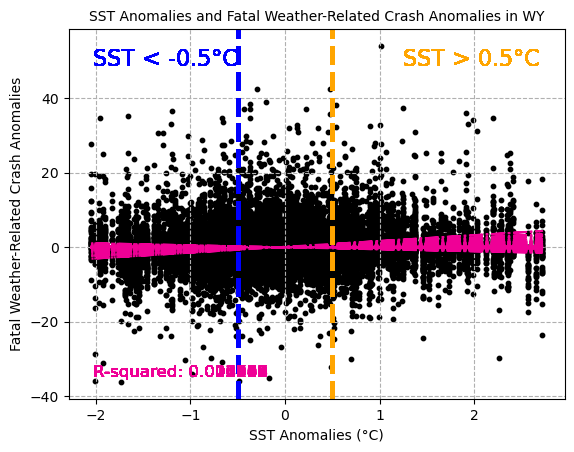

In [3]:
# Define your state_dict
state_dict = {
    1: 'AL',  # Alabama
    2: 'AK',  # Alaska
    4: 'AZ',  # Arizona
    5: 'AR',  # Arkansas
    6: 'CA',  # California
    8: 'CO',  # Colorado
    9: 'CT',  # Connecticut
    10: 'DE',  # Delaware
    11: 'DC',  # District of Columbia
    12: 'FL',  # Florida
    13: 'GA',  # Georgia
    15: 'HI',  # Hawaii
    16: 'ID',  # Idaho
    17: 'IL',  # Illinois
    18: 'IN',  # Indiana
    19: 'IA',  # Iowa
    20: 'KS',  # Kansas
    21: 'KY',  # Kentucky
    22: 'LA',  # Louisiana
    23: 'ME',  # Maine
    24: 'MD',  # Maryland
    25: 'MA',  # Massachusetts
    26: 'MI',  # Michigan
    27: 'MN',  # Minnesota
    28: 'MS',  # Mississippi
    29: 'MO',  # Missouri
    30: 'MT',  # Montana
    31: 'NE',  # Nebraska
    32: 'NV',  # Nevada
    33: 'NH',  # New Hampshire
    34: 'NJ',  # New Jersey
    35: 'NM',  # New Mexico
    36: 'NY',  # New York
    37: 'NC',  # North Carolina
    38: 'ND',  # North Dakota
    39: 'OH',  # Ohio
    40: 'OK',  # Oklahoma
    41: 'OR',  # Oregon
    42: 'PA',  # Pennsylvania
    44: 'RI',  # Rhode Island
    45: 'SC',  # South Carolina
    46: 'SD',  # South Dakota
    47: 'TN',  # Tennessee
    48: 'TX',  # Texas
    49: 'UT',  # Utah
    50: 'VT',  # Vermont
    51: 'VA',  # Virginia
    53: 'WA',  # Washington
    54: 'WV',  # West Virginia
    55: 'WI',  # Wisconsin
    56: 'WY'   # Wyoming
}





# Extract unique SST value for the state

# Iterate through states
for state in state_dict.keys():
    # Filter data for the current state
    state_df = df[df['STATE'] == state]
    
    # Year and month combinations for grouping
    gdf = state_df.groupby(['YEAR', 'MONTH',"SST_value"]).size().reset_index(name='Count')
    gdf.sort_values(['YEAR', 'MONTH',"SST_value"], inplace=True)
    
    # Average crashes for set month
    average_crashes = gdf.groupby('MONTH')['Count'].mean().reset_index()
    
    # Anomaly calculation as the difference between the calculated crashes and the average crashes
    line_values = gdf['SST_value'].values
    anomaly = gdf['Count'] - gdf['MONTH'].map(average_crashes.set_index('MONTH')['Count'])
    x = line_values
    y = anomaly
    res = stats.linregress(x, y)
    r_squared = res.rvalue**2
    
    # Plotting code
    font_size = 10
    plt.scatter(line_values, anomaly, color='black', label='Anomalies vs Crashes', s=10)
    plt.title(f'SST Anomalies and Fatal Weather-Related Crash Anomalies in {state_dict[state]}', fontsize=font_size)
    plt.xlabel('SST Anomalies (°C)', fontsize=font_size)
    plt.ylabel('Fatal Weather-Related Crash Anomalies', fontsize=font_size)
    plt.axvline(x=0.5, color='orange', linewidth=3.5, linestyle='--')
    plt.axvline(x=-0.5, color='blue', linewidth=3.5, linestyle='--')
        # Annotate with a relative position within the axes
    plt.annotate(
        'SST > 0.5°C',
        xy=(0.95, 0.95),  # position at 95% of the width and 95% of the height of the axes
        xycoords='axes fraction',  # use the axes for positioning
        fontsize=16,
        color='orange',
        horizontalalignment='right',  # right-align the text
        verticalalignment='top'  # top-align the text
    )
    plt.annotate(
        'SST < -0.5°C',
        xy=(0.05, 0.95),  # position at 5% of the width and 95% of the height of the axes
        xycoords='axes fraction',  # use the axes for positioning
        fontsize=16,
        color='blue',
        horizontalalignment='left',  # left-align the text
        verticalalignment='top'  # top-align the text
    )
    
    plt.grid(axis='both', linestyle='--')
    m, b = np.polyfit(line_values, anomaly, 1)
    plt.plot(line_values, m * line_values + b, linewidth=1.5, linestyle="dashdot", color='#EF0096')
    plt.annotate(
        f"R-squared: {r_squared:.6f}", 
        xy=(0.05, 0.05),  # position at 5% of the width and 5% of the height of the axes
        xycoords='axes fraction',  # use the axes for positioning
        fontsize=12, 
        color='#EF0096', 
        horizontalalignment='left',  # left-align the text
        verticalalignment='bottom'  # bottom-align the text
    )



In [4]:
len(line_values)

359

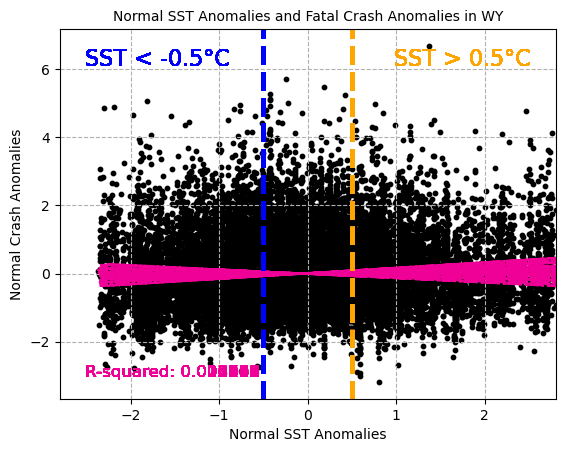

In [5]:
# Iterate through states
for state in state_dict.keys():
    # Filter data for the current state
    state_df = df[df['STATE'] == state]
    
    # Year and month combinations for grouping
    gdf = state_df.groupby(['YEAR', 'MONTH',"SST_value"]).size().reset_index(name='Count')
    gdf.sort_values(['YEAR', 'MONTH',"SST_value"], inplace=True)
    
    # Average crashes for set month
    average_crashes = gdf.groupby('MONTH')['Count'].mean().reset_index()
    
   # Anomaly calculation as the difference between the calculated crashes and the average crashes
    line_values = gdf['SST_value'].values
    anomaly = gdf['Count'] - gdf['MONTH'].map(average_crashes.set_index('MONTH')['Count'])
    
    # Standard deviation calculation
    x_std = np.std(line_values)
    y_std = np.std(anomaly)
    
    # Normalize anomalies
    x_normalized = line_values / x_std if x_std != 0 else line_values
    y_normalized = anomaly / y_std if y_std != 0 else anomaly

    res = stats.linregress(x_normalized, y_normalized)
    r_squared = res.rvalue**2
    
    # Plotting code
    font_size = 10
    plt.scatter(x_normalized, y_normalized, color='black', label='Normalized Anomalies vs Crashes', s=10)
    plt.title(f'Normal SST Anomalies and Fatal Crash Anomalies in {state_dict[state]}', fontsize=font_size)
    plt.xlabel('Normal SST Anomalies', fontsize=font_size)
    plt.ylabel('Normal Crash Anomalies', fontsize=font_size)
    plt.xlim(-2.8, 2.8) 
    plt.axvline(x=0.5, color='orange', linewidth=3.5, linestyle='--')
    plt.axvline(x=-0.5, color='blue', linewidth=3.5, linestyle='--')
    plt.annotate(
        'SST > 0.5°C',
        xy=(0.95, 0.95),  # position at 95% of the width and 95% of the height of the axes
        xycoords='axes fraction',  # use the axes for positioning
        fontsize=16,
        color='orange',
        horizontalalignment='right',  # right-align the text
        verticalalignment='top'  # top-align the text
    )
    plt.annotate(
        'SST < -0.5°C',
        xy=(0.05, 0.95),  # position at 5% of the width and 95% of the height of the axes
        xycoords='axes fraction',  # use the axes for positioning
        fontsize=16,
        color='blue',
        horizontalalignment='left',  # left-align the text
        verticalalignment='top'  # top-align the text
    )
    plt.grid(axis='both', linestyle='--')
    m, b = np.polyfit(x_normalized, y_normalized, 1)
    plt.plot(x_normalized, m * x_normalized + b, linewidth=1.5, linestyle="dashdot", color='#EF0096')
    plt.annotate(
        f"R-squared: {r_squared:.6f}", 
        xy=(0.05, 0.05),  # position at 5% of the width and 5% of the height of the axes
        xycoords='axes fraction',  # use the axes for positioning
        fontsize=12, 
        color='#EF0096', 
        horizontalalignment='left',  # left-align the text
        verticalalignment='bottom'  # bottom-align the text
    )



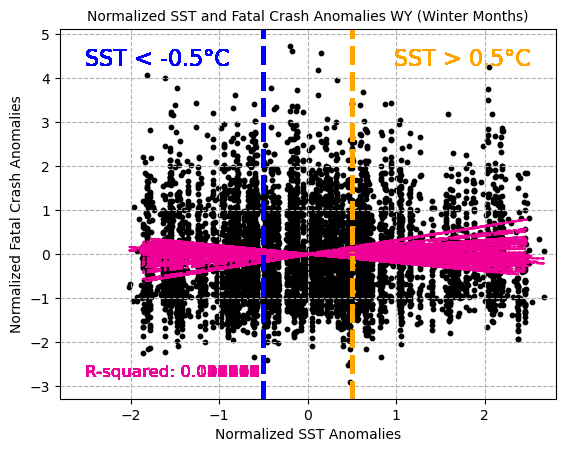

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

for state in state_dict.keys():
    # Filter data for the current state
    state_df = df[df['STATE'] == state]
    
    # Filter for winter months (December, January, February)
    winter_months = [12, 1, 2]
    winter_df = state_df[state_df['MONTH'].isin(winter_months)]
    
    # Year and month combinations for grouping
    gdf = winter_df.groupby(['YEAR', 'MONTH', "SST_value"]).size().reset_index(name='Count')
    gdf.sort_values(['YEAR', 'MONTH', "SST_value"], inplace=True)
    
    # Average crashes for winter months
    average_crashes = gdf.groupby('MONTH')['Count'].mean().reset_index()
    
    # Anomaly calculation as the difference between the calculated crashes and the average crashes
    line_values = gdf['SST_value'].values
    anomaly = gdf['Count'] - gdf['MONTH'].map(average_crashes.set_index('MONTH')['Count'])
    
    # Standard deviation calculation
    x_std = np.std(line_values)
    y_std = np.std(anomaly)
    
    # Normalize anomalies
    x_normalized = line_values / x_std if x_std != 0 else line_values
    y_normalized = anomaly / y_std if y_std != 0 else anomaly

    res = stats.linregress(x_normalized, y_normalized)
    r_squared = res.rvalue**2
    
    # Plotting code
    font_size = 10
    plt.scatter(x_normalized, y_normalized, color='black', label='Normalized Anomalies vs Crashes', s=10)
    plt.title(f'Normalized SST and Fatal Crash Anomalies {state_dict[state]} (Winter Months)', fontsize=font_size)
    plt.xlabel('Normalized SST Anomalies', fontsize=font_size)
    plt.ylabel('Normalized Fatal Crash Anomalies', fontsize=font_size)
    plt.xlim(-2.8, 2.8) 
    plt.axvline(x=0.5, color='orange', linewidth=3.5, linestyle='--')
    plt.axvline(x=-0.5, color='blue', linewidth=3.5, linestyle='--')
    plt.annotate(
        'SST > 0.5°C',
        xy=(0.95, 0.95),
        xycoords='axes fraction',
        fontsize=16,
        color='orange',
        horizontalalignment='right',
        verticalalignment='top'
    )
    plt.annotate(
        'SST < -0.5°C',
        xy=(0.05, 0.95),
        xycoords='axes fraction',
        fontsize=16,
        color='blue',
        horizontalalignment='left',
        verticalalignment='top'
    )
    plt.grid(axis='both', linestyle='--')
    m, b = np.polyfit(x_normalized, y_normalized, 1)
    plt.plot(x_normalized, m * x_normalized + b, linewidth=1.5, linestyle="dashdot", color='#EF0096')
    plt.annotate(
        f"R-squared: {r_squared:.6f}", 
        xy=(0.05, 0.05),
        xycoords='axes fraction',
        fontsize=12, 
        color='#EF0096', 
        horizontalalignment='left',
        verticalalignment='bottom'
    )



Processing state: AL
No precipitation anomaly data for state: AK, skipping...
Processing state: AZ
Processing state: AR
Processing state: CA
Processing state: CO
Processing state: CT
Processing state: DE
No precipitation anomaly data for state: DC, skipping...
Processing state: FL
Processing state: GA
No precipitation anomaly data for state: HI, skipping...
Processing state: ID
Processing state: IL
Processing state: IN
Processing state: IA
Processing state: KS
Processing state: KY
Processing state: LA
Processing state: ME
Processing state: MD
Processing state: MA
Processing state: MI
Processing state: MN
Processing state: MS
Processing state: MO
Processing state: MT
Processing state: NE
Processing state: NV
Processing state: NH
Processing state: NJ
Processing state: NM
Processing state: NY
Processing state: NC
Processing state: ND
Processing state: OH
Processing state: OK
Processing state: OR
Processing state: PA
Processing state: RI
Processing state: SC
Processing state: SD
Processing

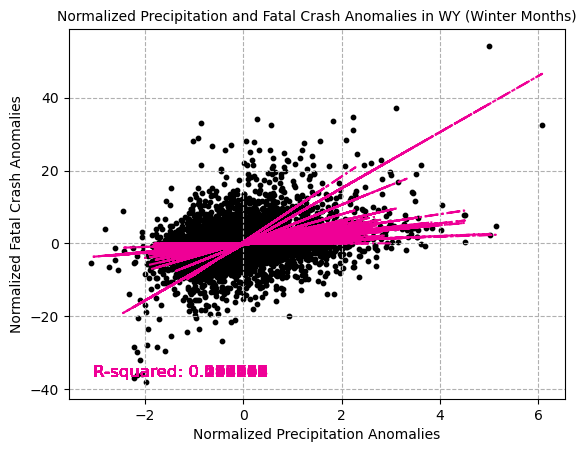

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Load your crash data and precipitation data



# Normalize the precipitation anomalies for each state
for col in precip_data.columns:
    if col.startswith('Precip_Anomaly_'):
        state_abbr = col.split('_')[-1]
        precip_data[col] = (precip_data[col] - precip_data[col].mean()) / precip_data[col].std()

# Convert 'Year-Month' in precipitation data to separate 'YEAR' and 'MONTH' columns
precip_data['Year-Month'] = pd.to_datetime(precip_data['Year-Month'])
precip_data['YEAR'] = precip_data['Year-Month'].dt.year
precip_data['MONTH'] = precip_data['Year-Month'].dt.month

# Ensure that 'YEAR' and 'MONTH' in crash data are integers
df['YEAR'] = df['YEAR'].astype(int)
df['MONTH'] = df['MONTH'].astype(int)

for state in state_dict.keys():
    state_abbr = state_dict[state]
    precip_column = f'Precip_Anomaly_{state_abbr}'

    # Check if the precipitation anomaly column for the state exists in the dataset
    if precip_column not in precip_data.columns:
        print(f"No precipitation anomaly data for state: {state_abbr}, skipping...")
        continue

    print(f"Processing state: {state_abbr}")

    # Filter data for the current state
    state_df = df[df['STATE'] == state]
    if state_df.empty:
        print(f"No crash data for state: {state_abbr}")
        continue


    # Filter for winter months (December, January, February)
    winter_months = [12, 1, 2]
    winter_df = state_df[state_df['MONTH'].isin(winter_months)]

    # Join with the normalized precipitation data
    joined_df = winter_df.merge(precip_data, on=['YEAR', 'MONTH'])

    # Year and month combinations for grouping
    gdf = joined_df.groupby(['YEAR', 'MONTH', f"Precip_Anomaly_{state_dict[state]}"]).size().reset_index(name='Count')
    gdf.sort_values(['YEAR', 'MONTH', f"Precip_Anomaly_{state_dict[state]}"], inplace=True)

    # Average crashes for winter months
    average_crashes = gdf.groupby('MONTH')['Count'].mean().reset_index()

    # Anomaly calculation
    anomaly = gdf['Count'] - gdf['MONTH'].map(average_crashes.set_index('MONTH')['Count'])
    
    # Normalized precipitation anomalies
    precip_normalized = gdf[f"Precip_Anomaly_{state_dict[state]}"]

    res = stats.linregress(precip_normalized, anomaly)
    r_squared = res.rvalue**2

    # Plotting code
    font_size = 10
    plt.scatter(precip_normalized, anomaly, color='black', label='Normalized Anomalies vs Crashes', s=10)
    plt.title(f'Normalized Precipitation and Fatal Crash Anomalies in {state_dict[state]} (Winter Months)', fontsize=font_size)
    plt.xlabel('Normalized Precipitation Anomalies', fontsize=font_size)
    plt.ylabel('Normalized Fatal Crash Anomalies', fontsize=font_size)
    plt.grid(axis='both', linestyle='--')
    m, b = np.polyfit(precip_normalized, anomaly, 1)
    plt.plot(precip_normalized, m * precip_normalized + b, linewidth=1.5, linestyle="dashdot", color='#EF0096')
    plt.annotate(f"R-squared: {r_squared:.6f}", xy=(0.05, 0.05), xycoords='axes fraction', fontsize=12, color='#EF0096', horizontalalignment='left', verticalalignment='bottom')

 


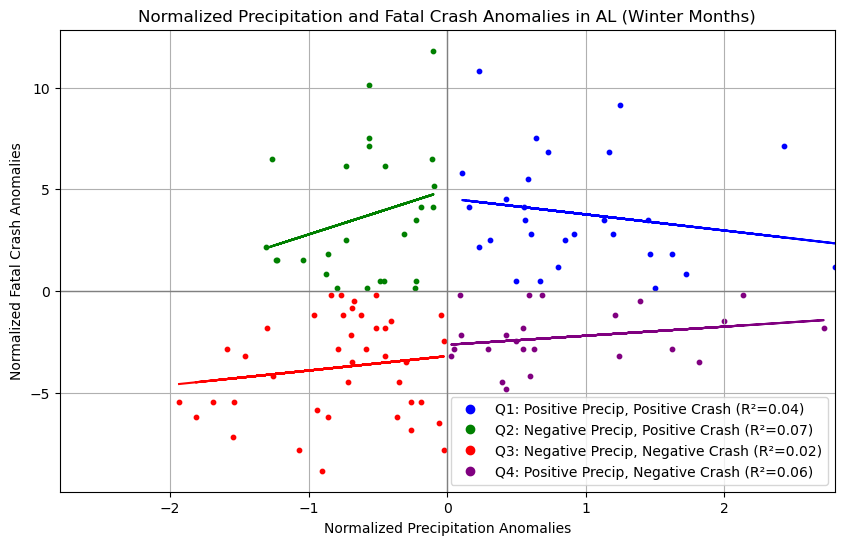

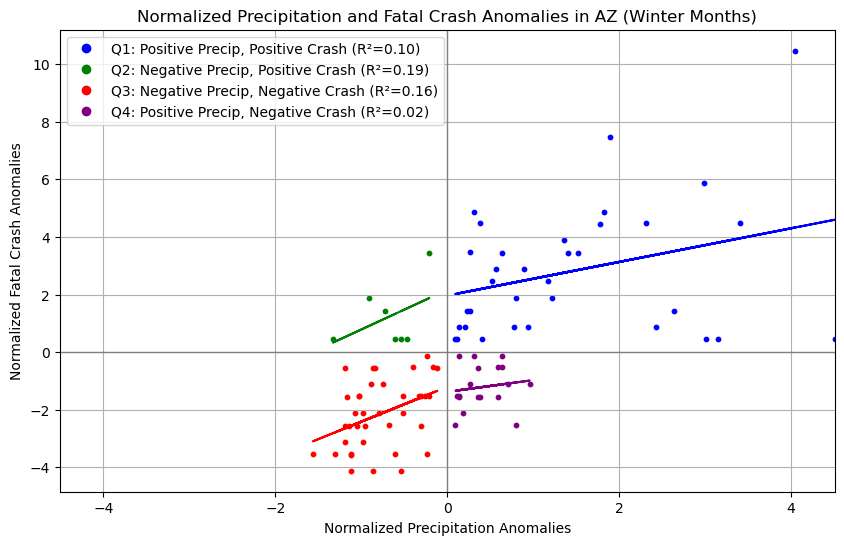

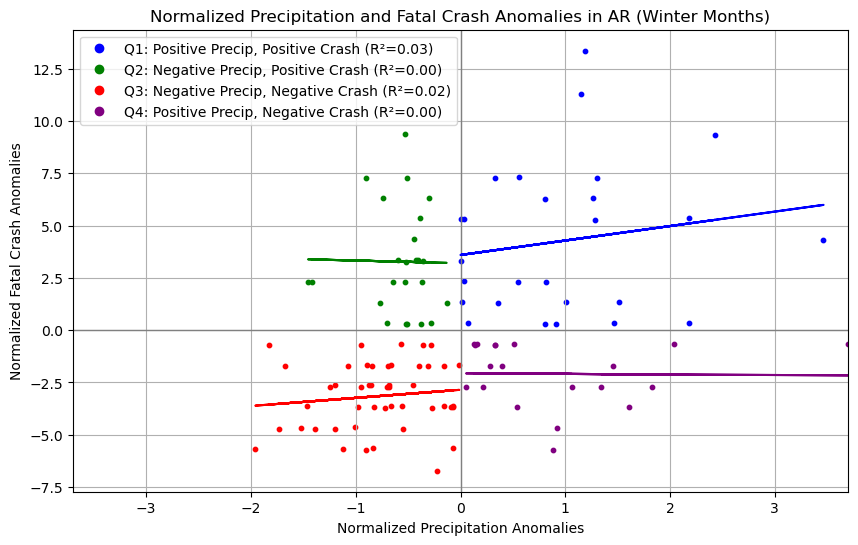

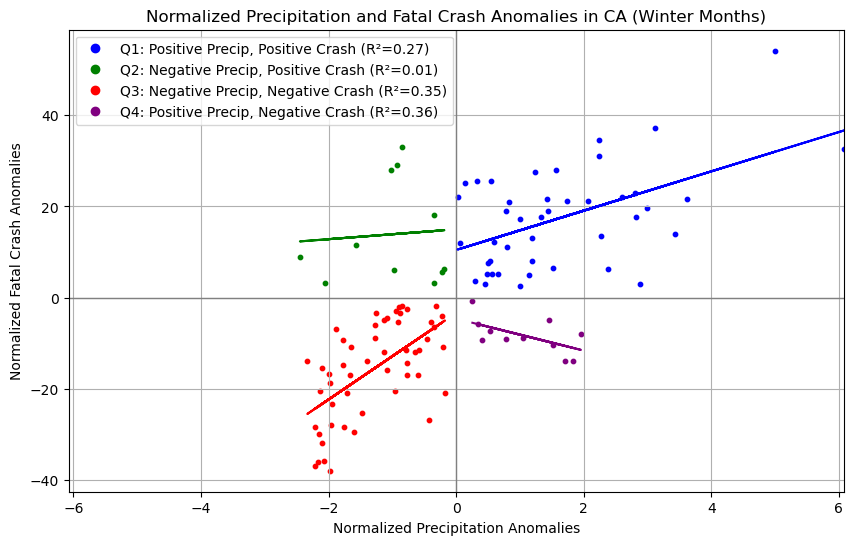

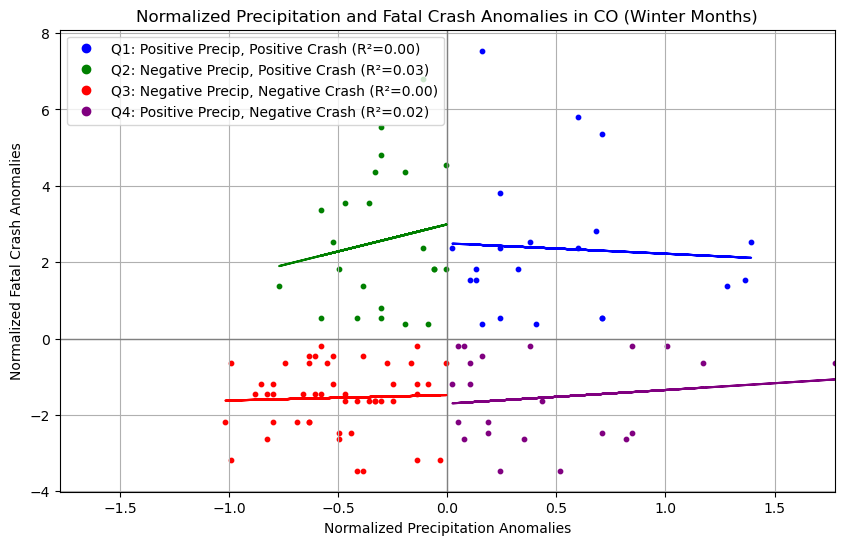

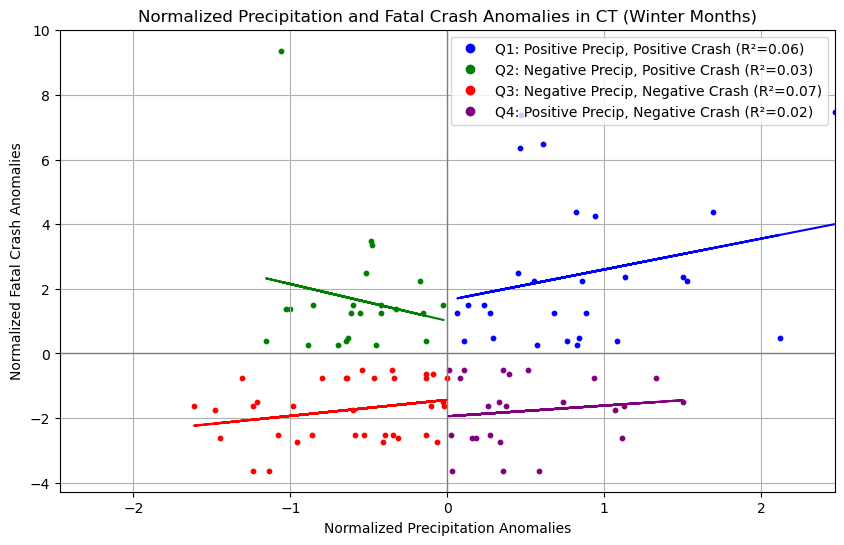

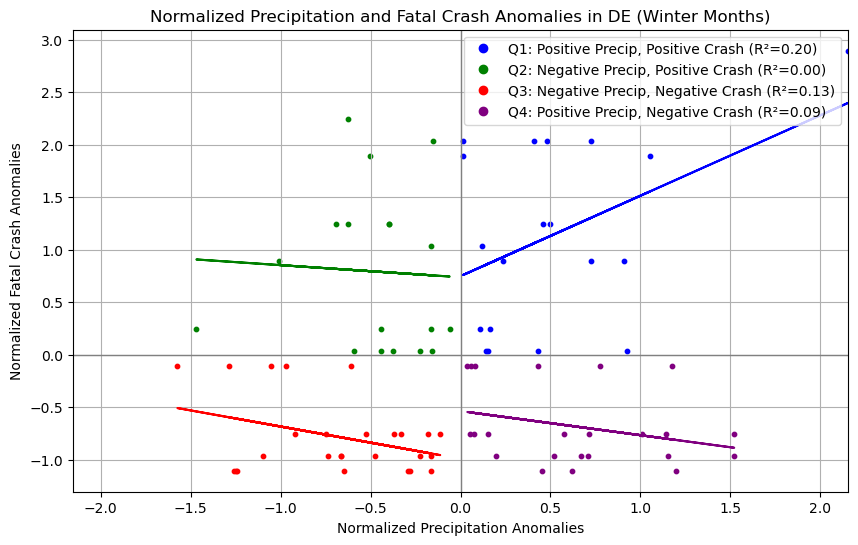

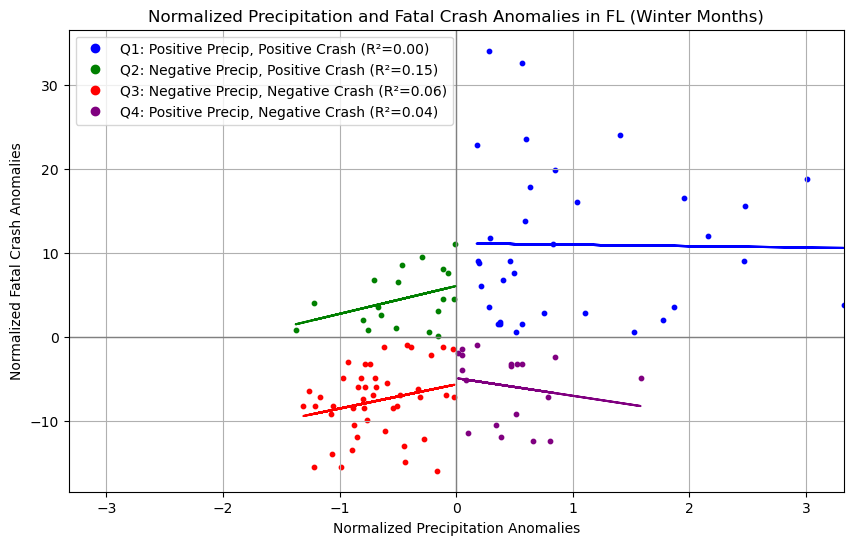

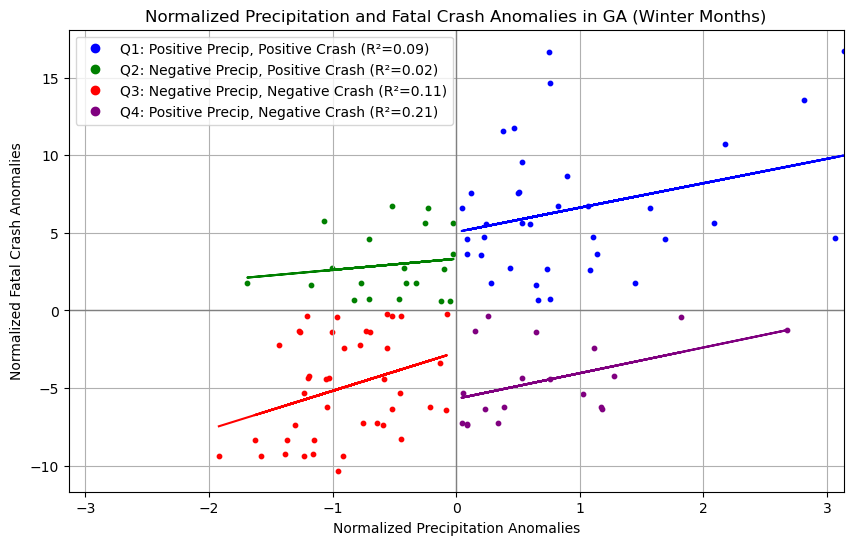

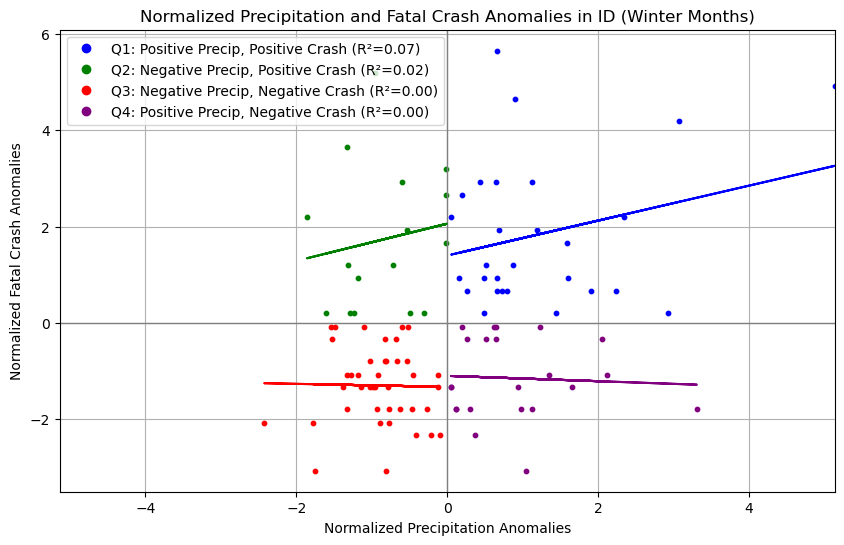

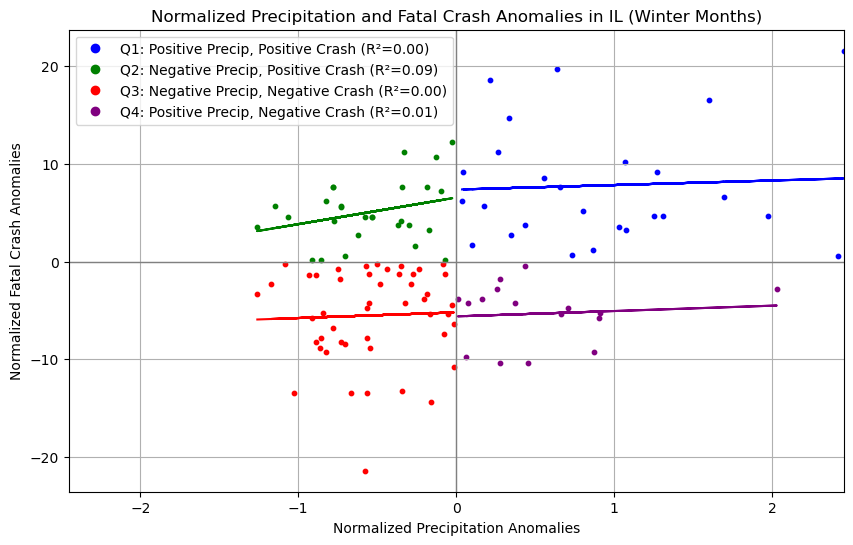

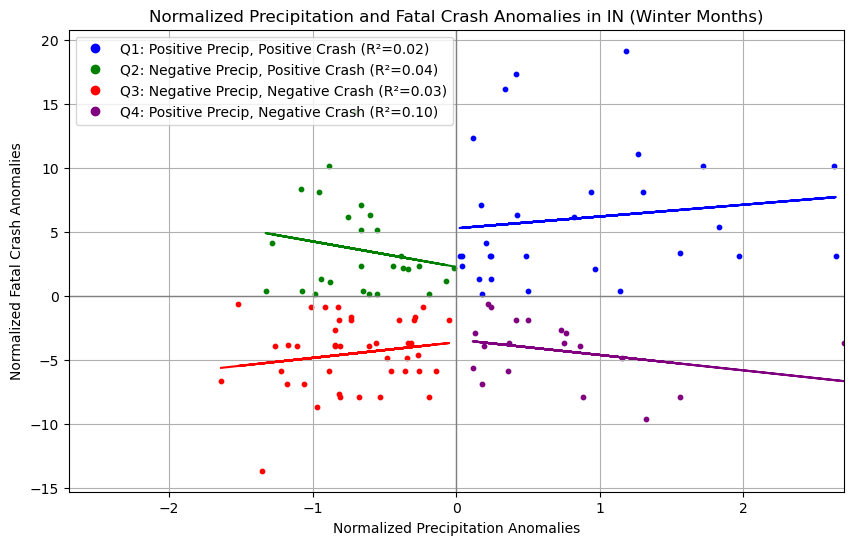

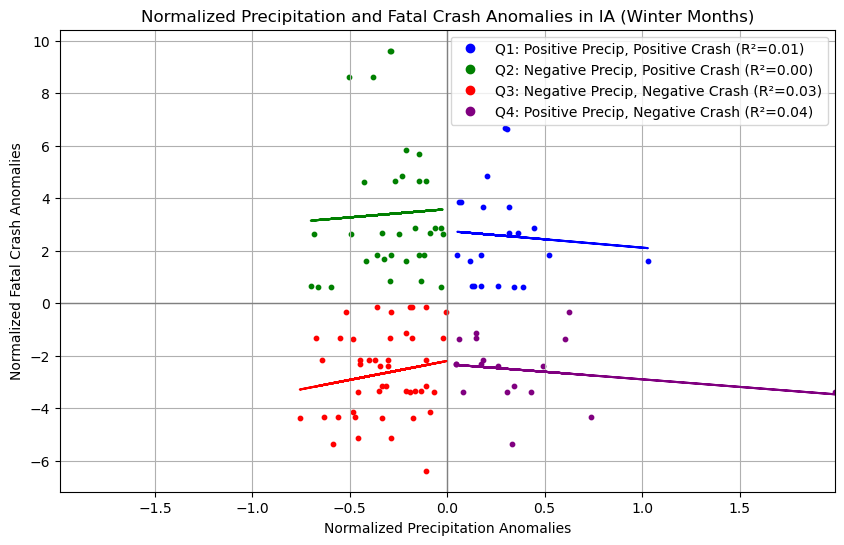

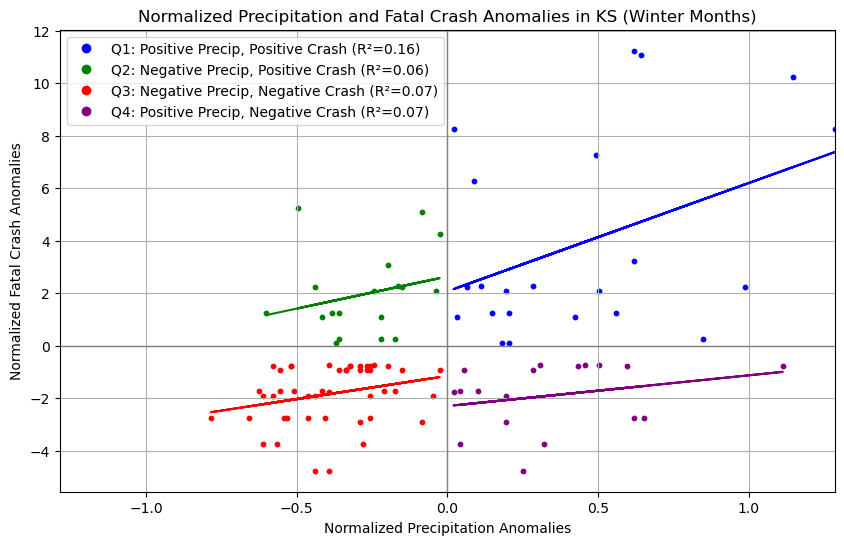

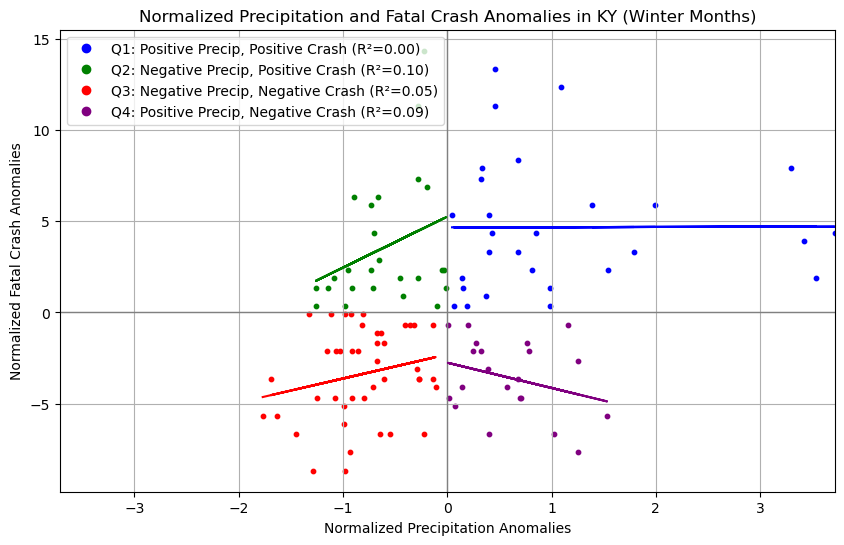

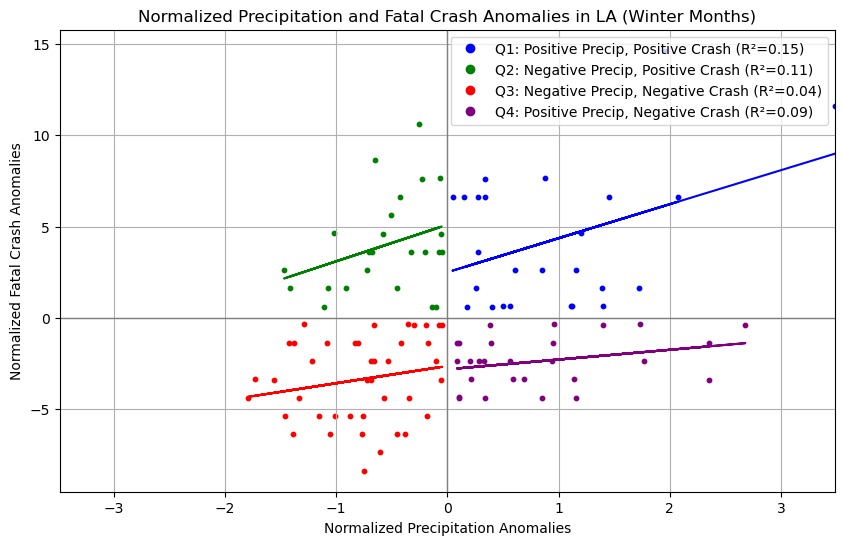

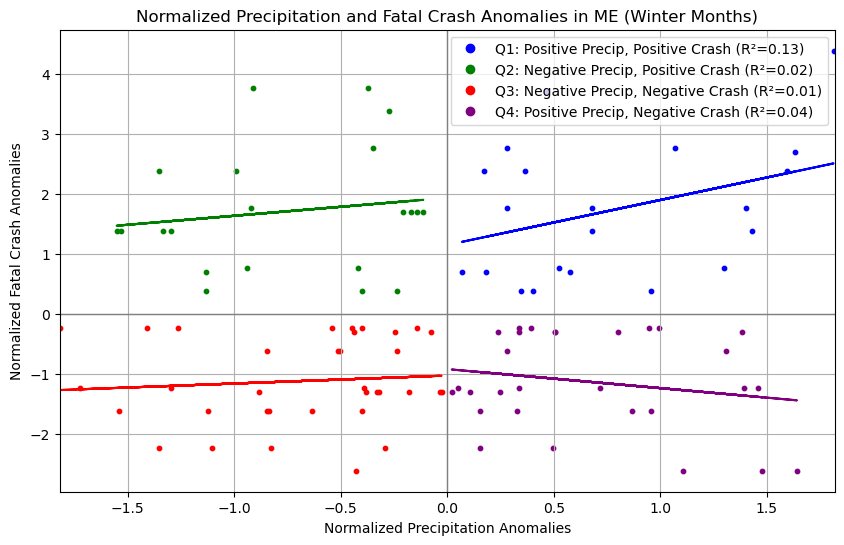

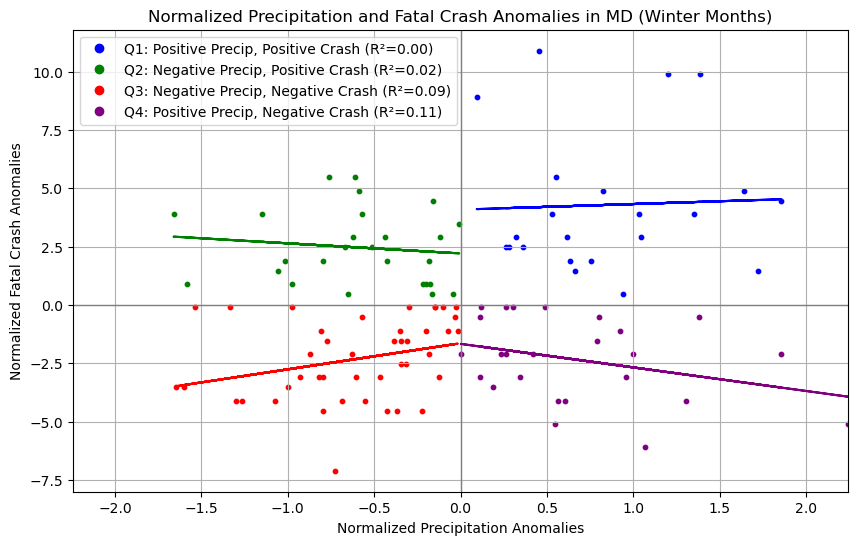

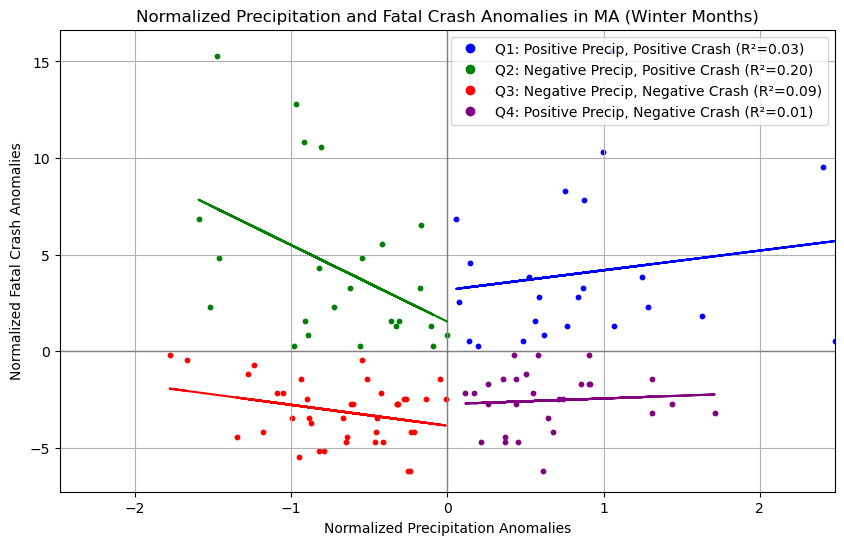

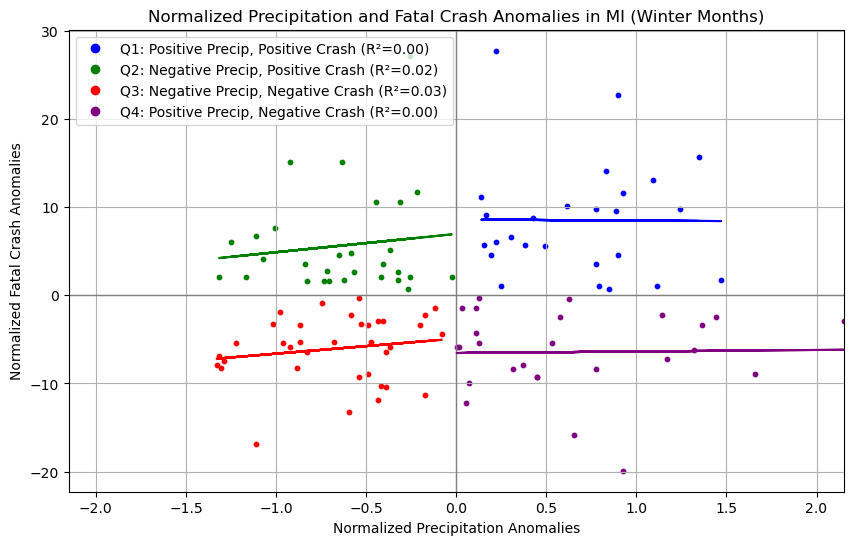

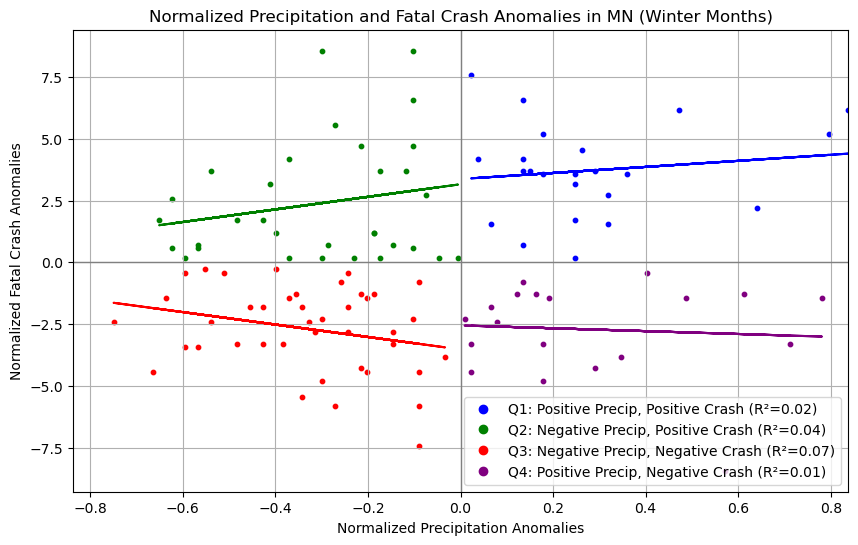

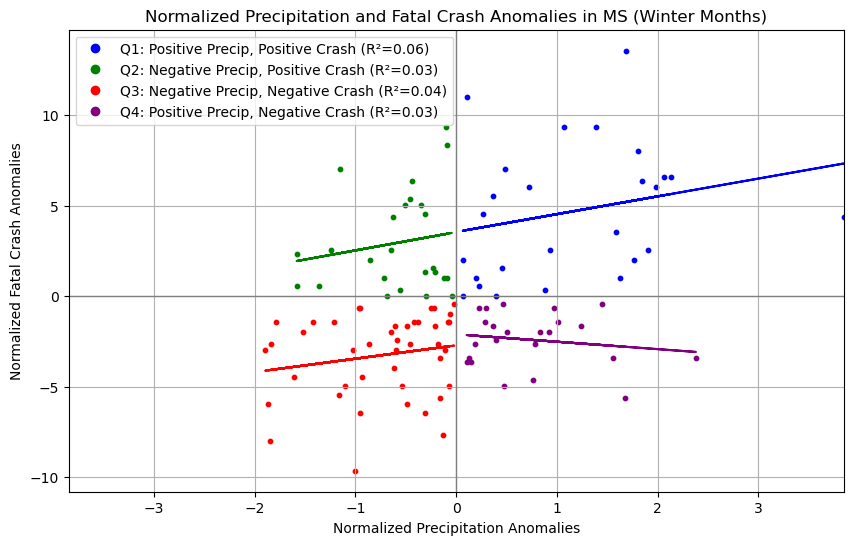

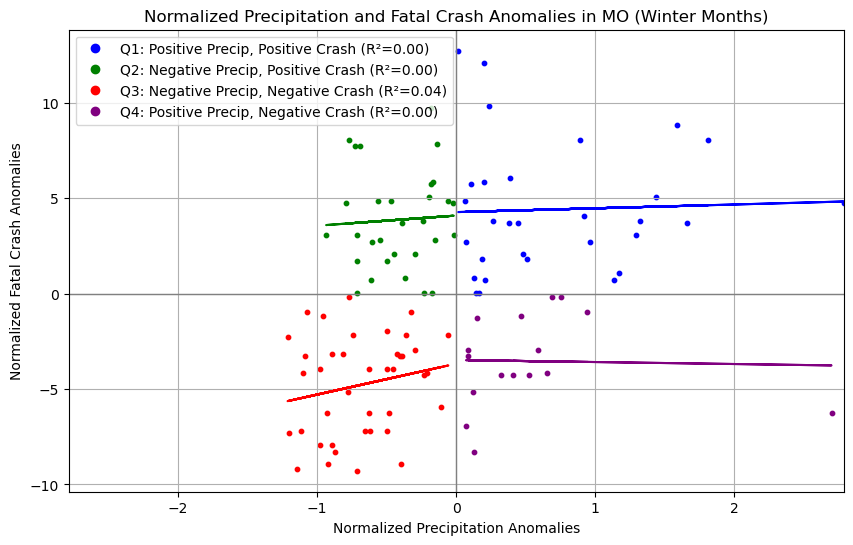

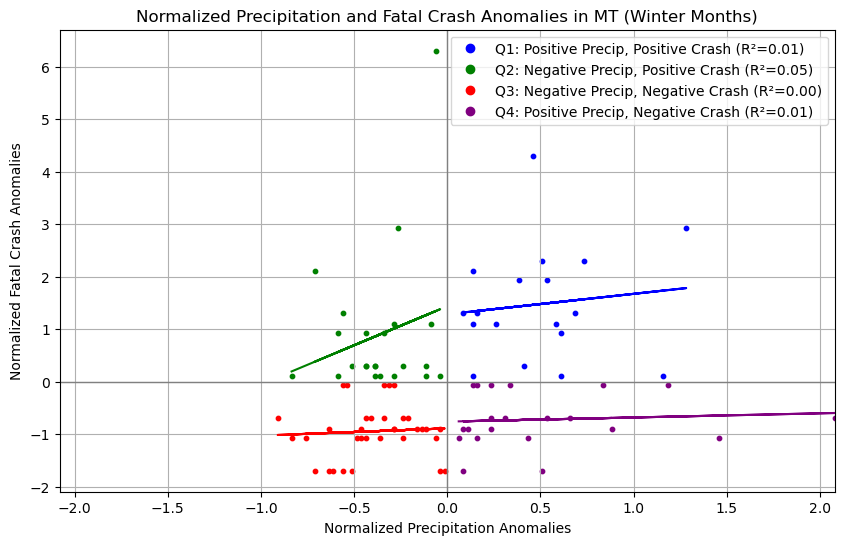

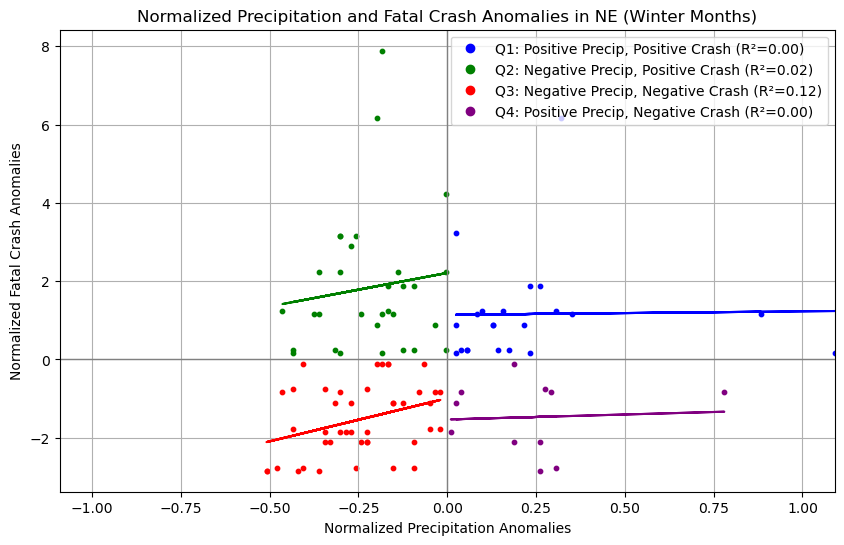

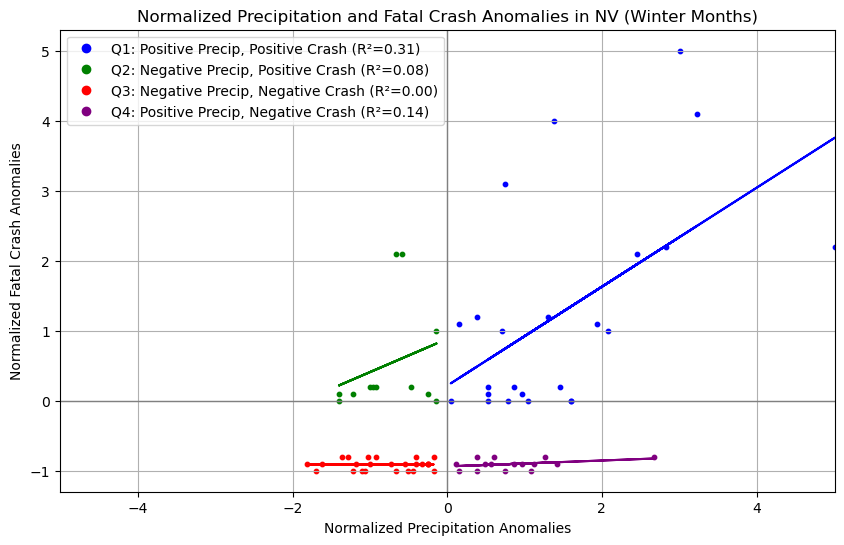

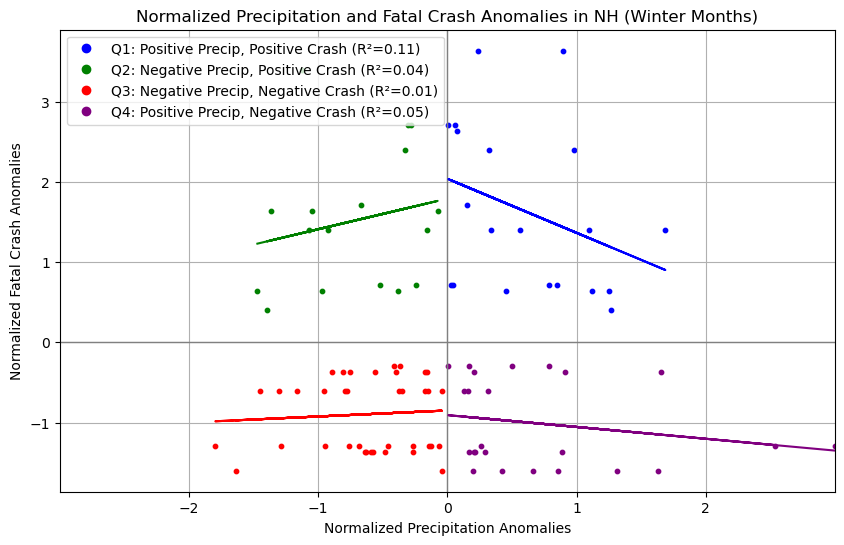

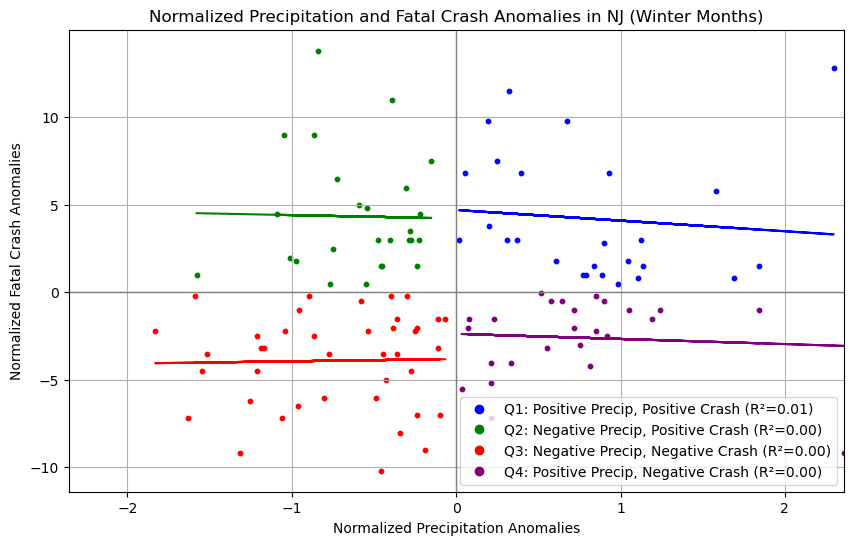

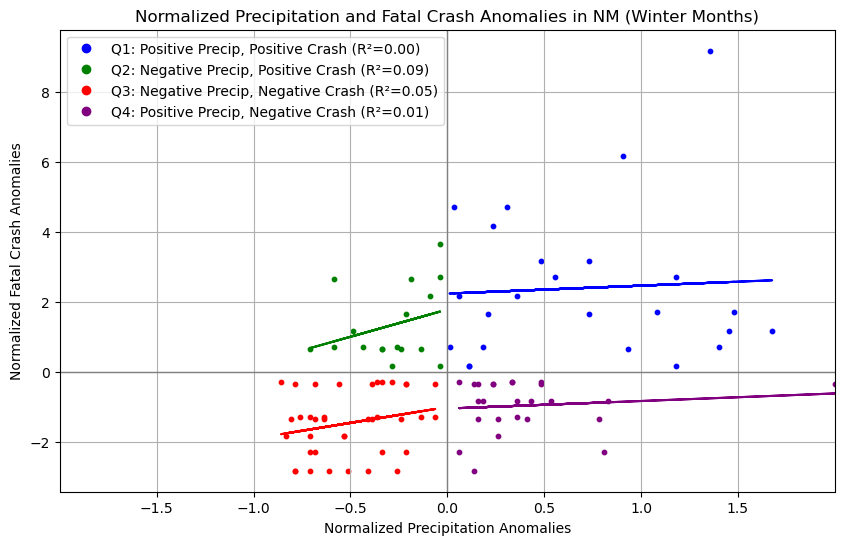

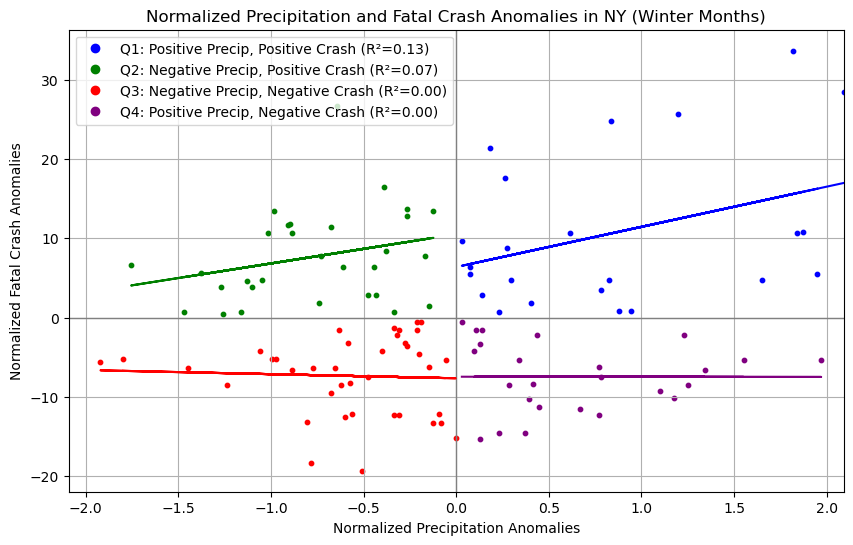

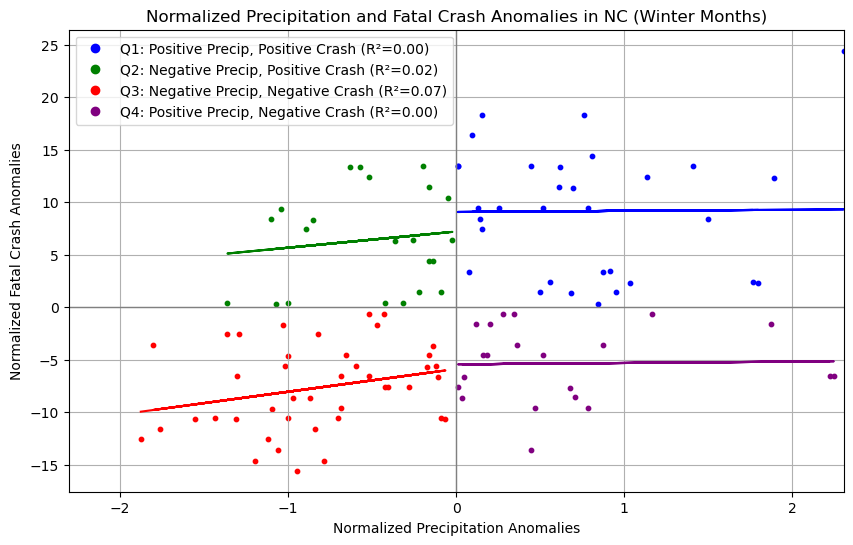

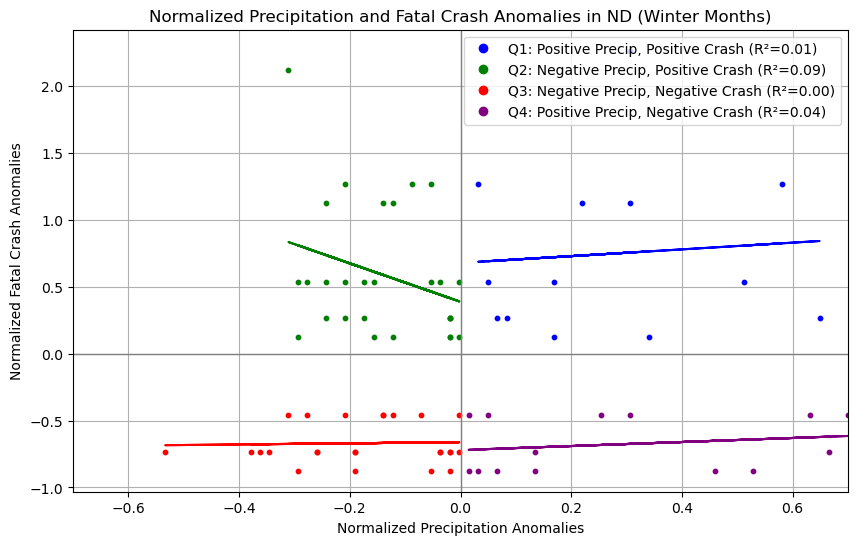

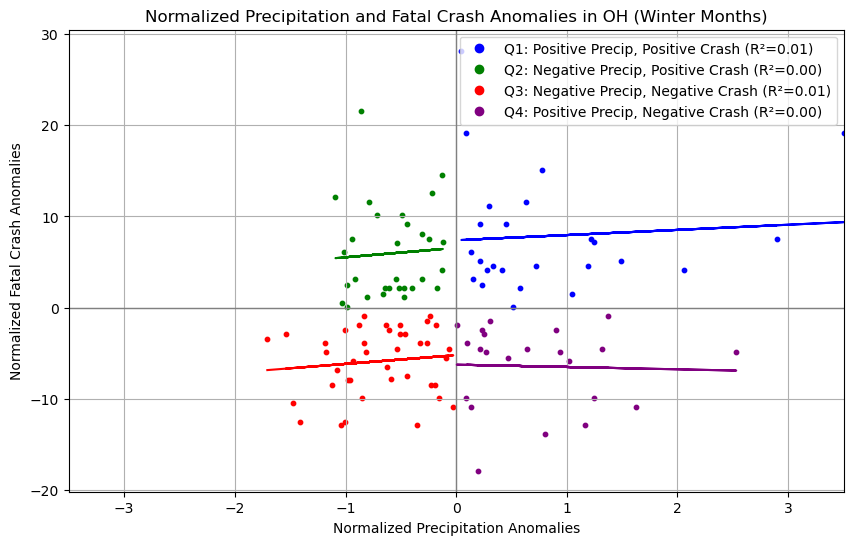

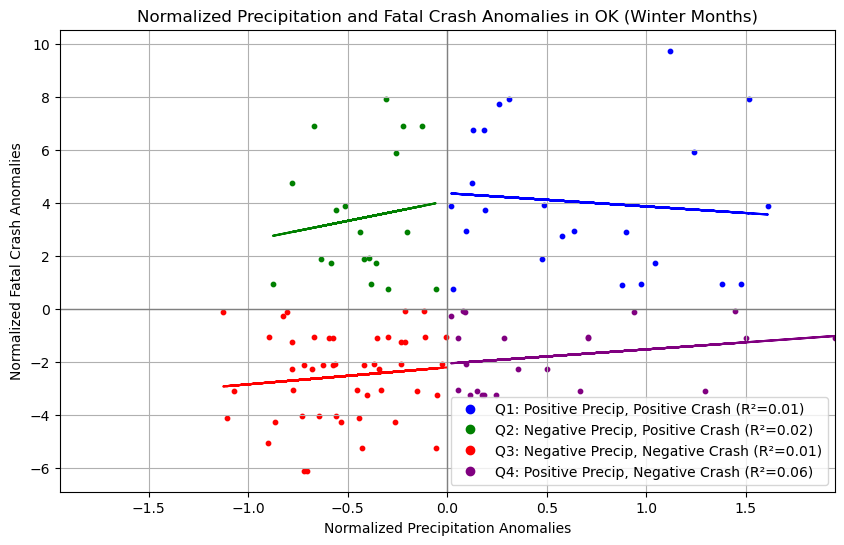

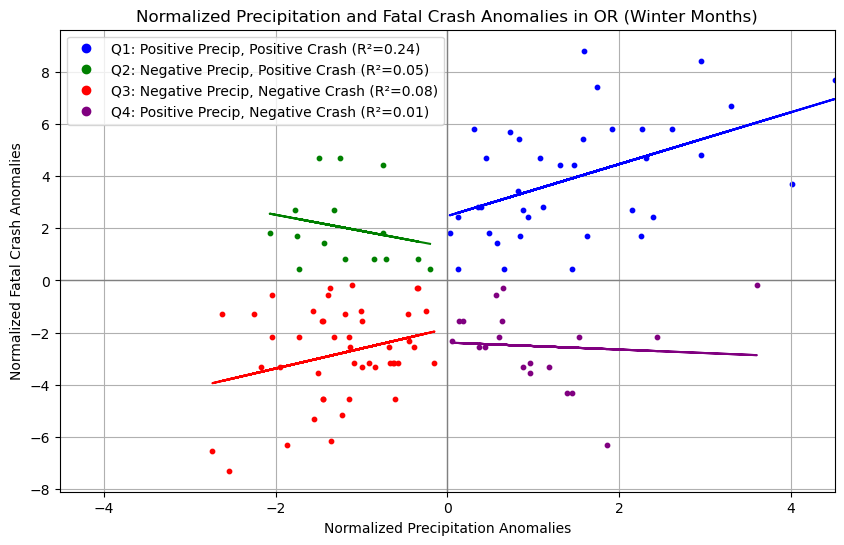

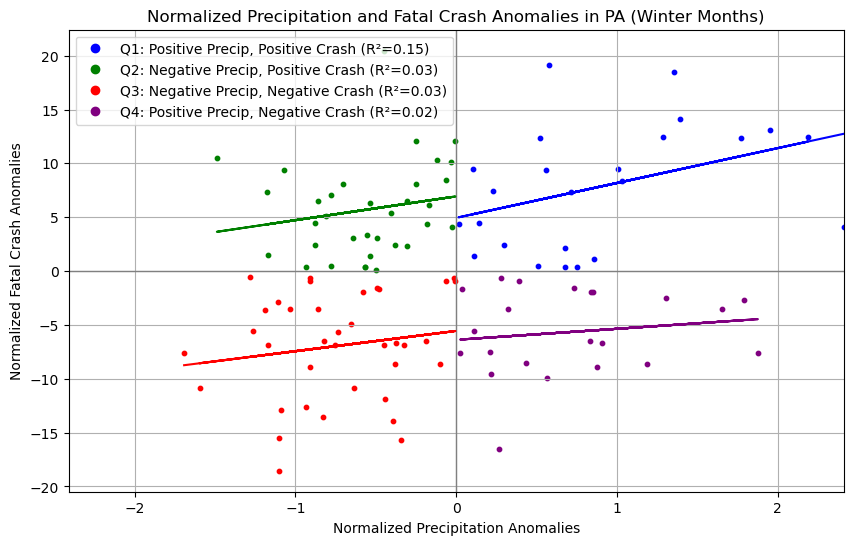

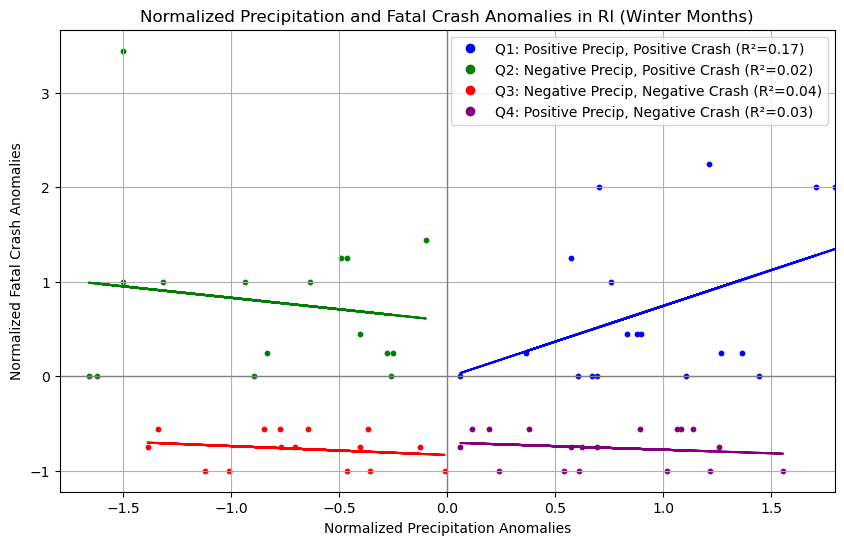

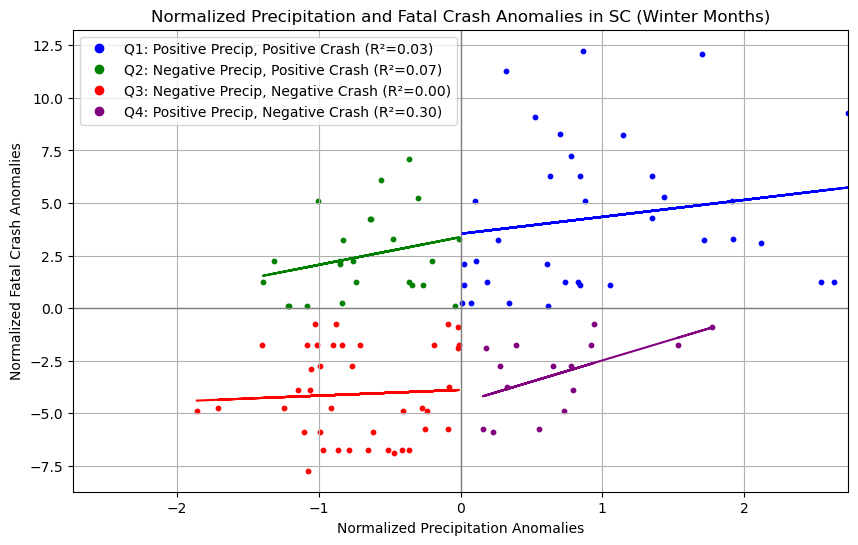

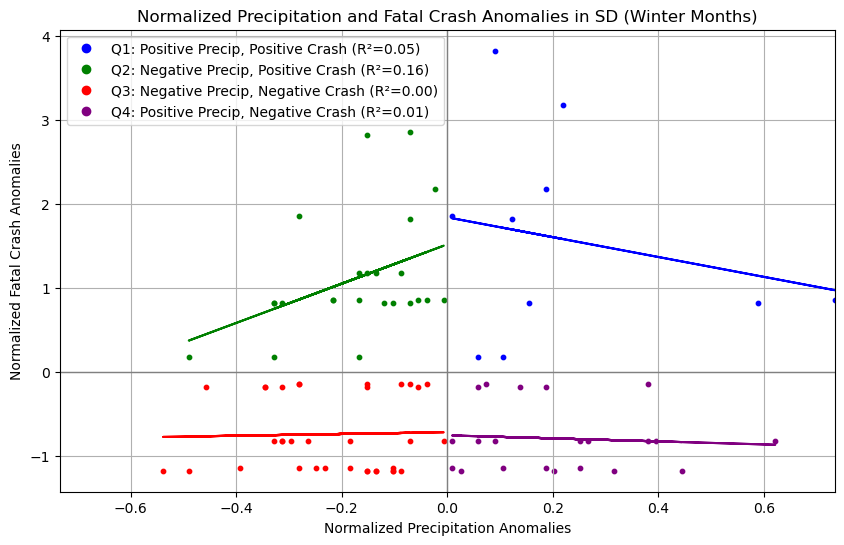

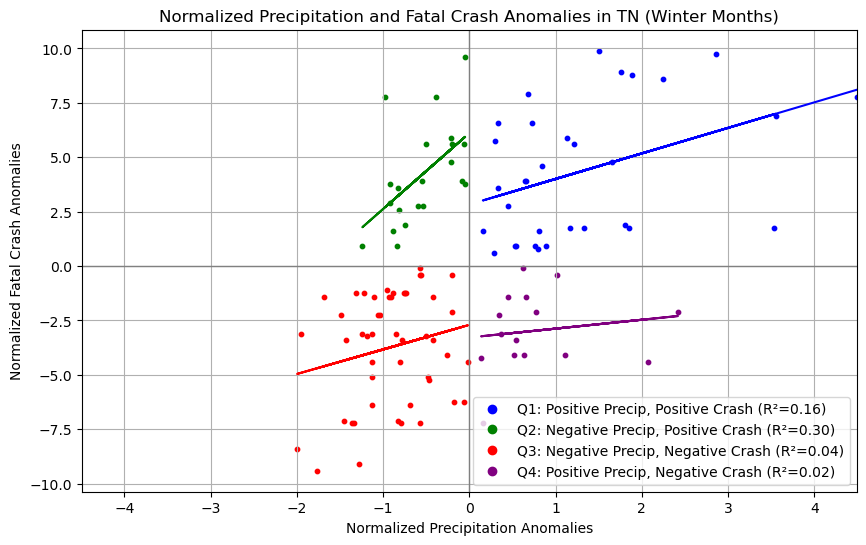

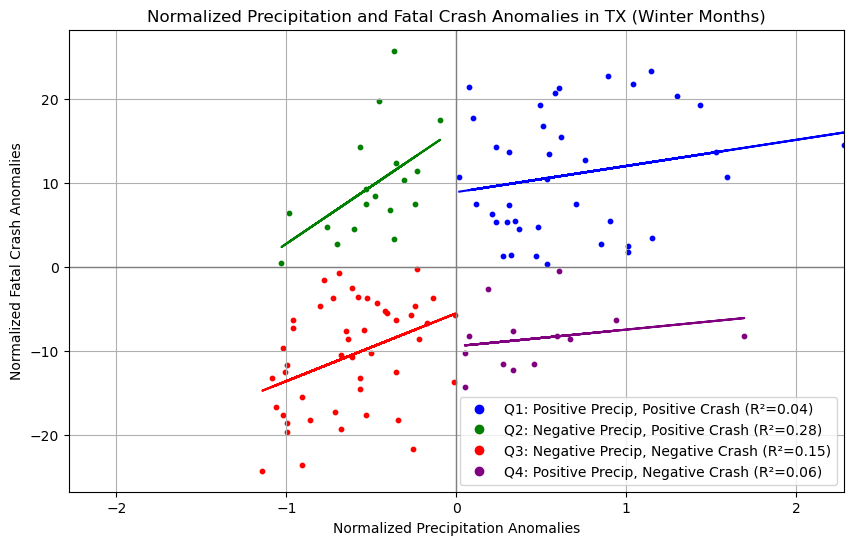

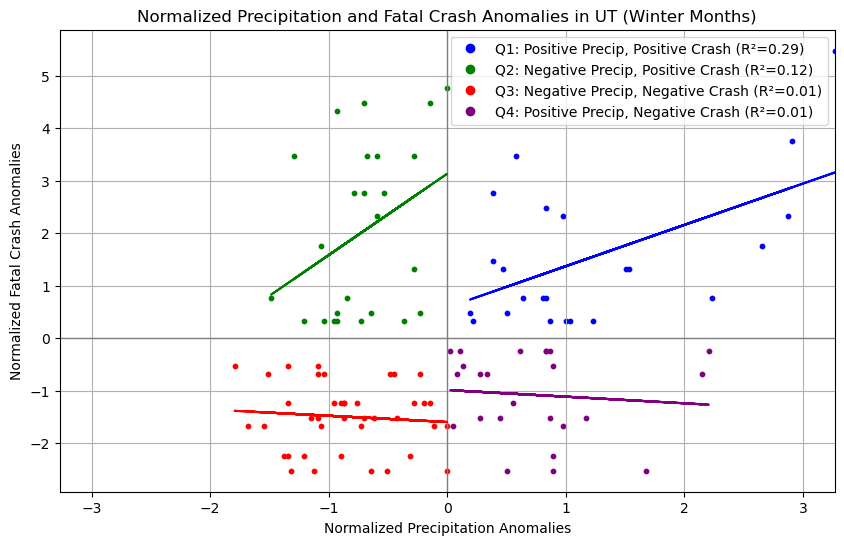

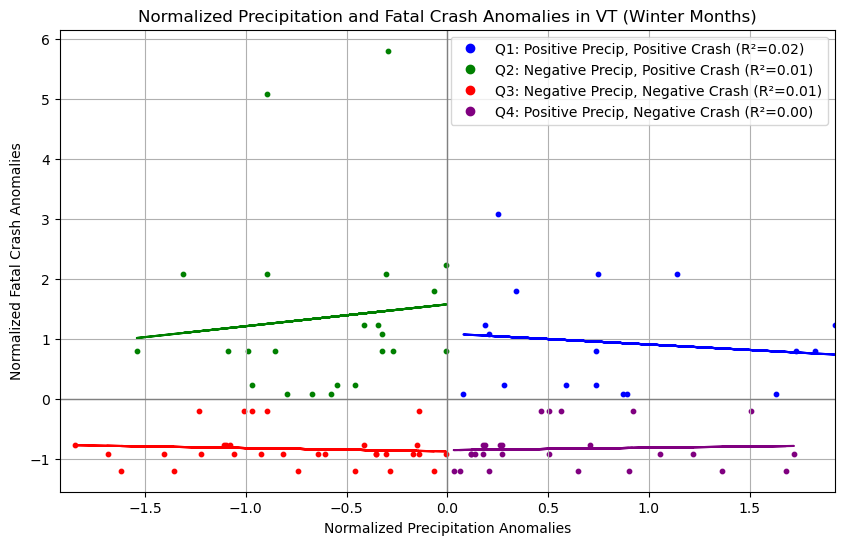

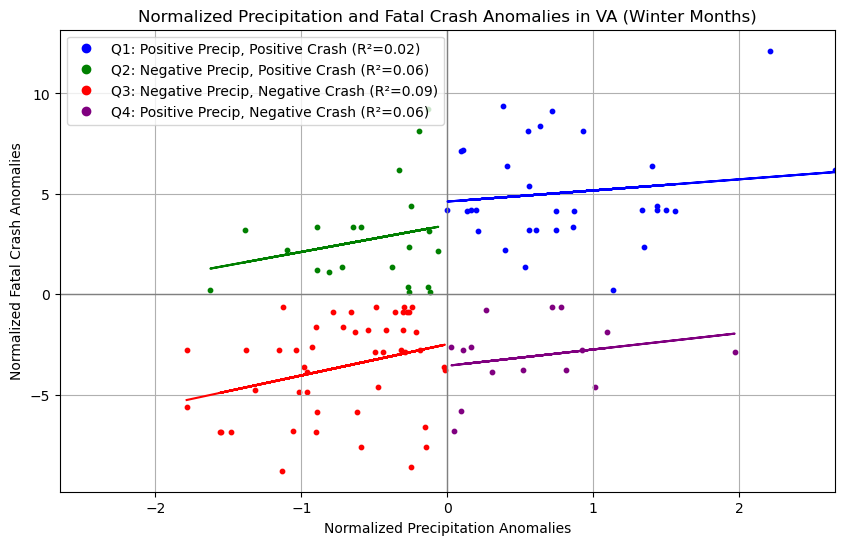

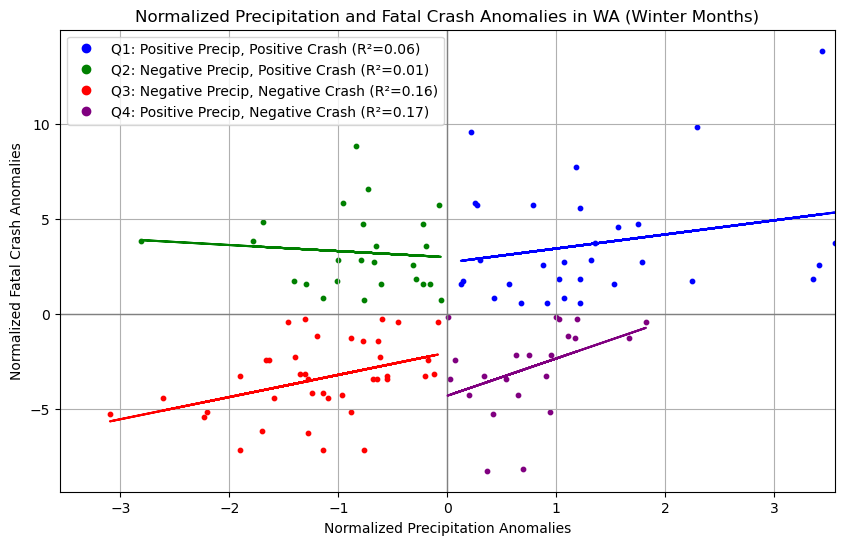

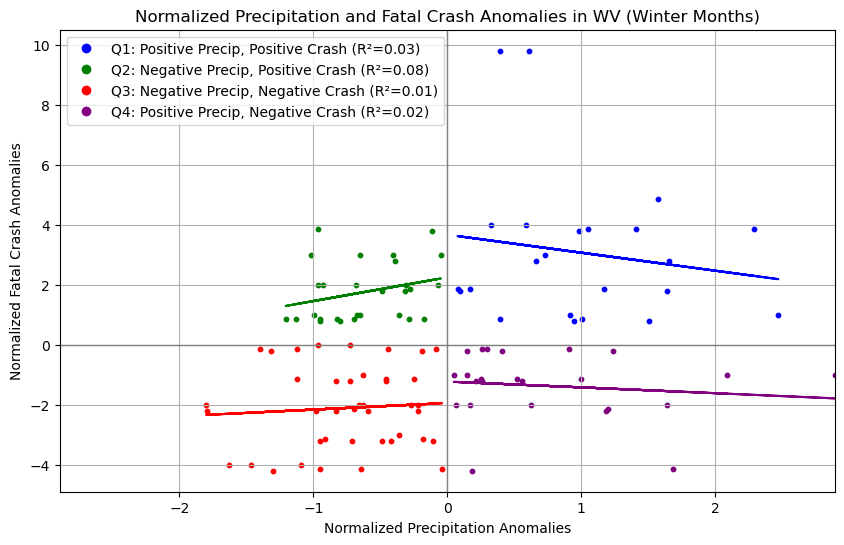

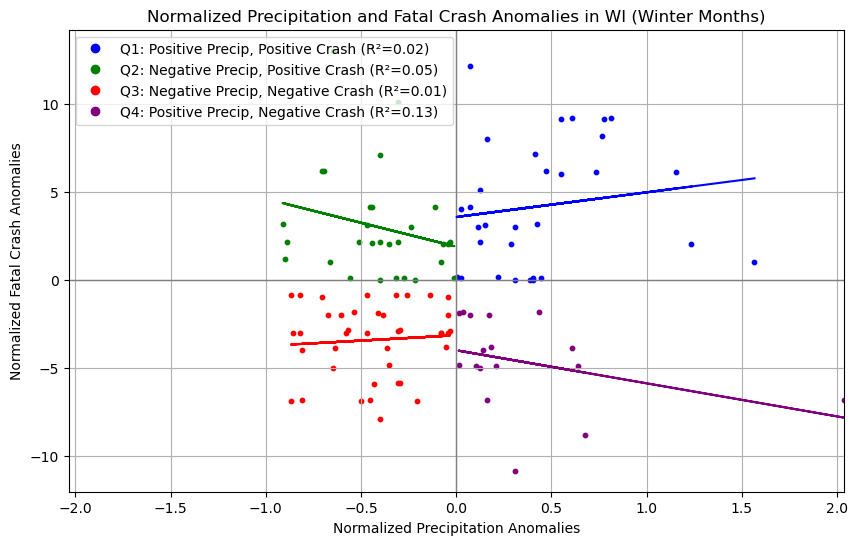

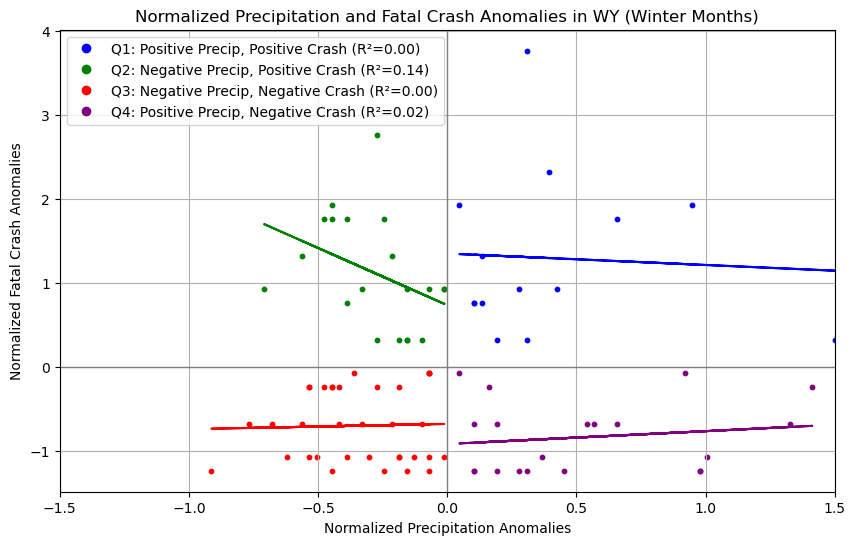

In [8]:
import matplotlib.lines as mlines
state_dict = {
    1: 'AL',  # Alabama
    2: 'AK',  # Alaska
    4: 'AZ',  # Arizona
    5: 'AR',  # Arkansas
    6: 'CA',  # California
    8: 'CO',  # Colorado
    9: 'CT',  # Connecticut
    10: 'DE',  # Delaware
    11: 'DC',  # District of Columbia
    12: 'FL',  # Florida
    13: 'GA',  # Georgia
    15: 'HI',  # Hawaii
    16: 'ID',  # Idaho
    17: 'IL',  # Illinois
    18: 'IN',  # Indiana
    19: 'IA',  # Iowa
    20: 'KS',  # Kansas
    21: 'KY',  # Kentucky
    22: 'LA',  # Louisiana
    23: 'ME',  # Maine
    24: 'MD',  # Maryland
    25: 'MA',  # Massachusetts
    26: 'MI',  # Michigan
    27: 'MN',  # Minnesota
    28: 'MS',  # Mississippi
    29: 'MO',  # Missouri
    30: 'MT',  # Montana
    31: 'NE',  # Nebraska
    32: 'NV',  # Nevada
    33: 'NH',  # New Hampshire
    34: 'NJ',  # New Jersey
    35: 'NM',  # New Mexico
    36: 'NY',  # New York
    37: 'NC',  # North Carolina
    38: 'ND',  # North Dakota
    39: 'OH',  # Ohio
    40: 'OK',  # Oklahoma
    41: 'OR',  # Oregon
    42: 'PA',  # Pennsylvania
    44: 'RI',  # Rhode Island
    45: 'SC',  # South Carolina
    46: 'SD',  # South Dakota
    47: 'TN',  # Tennessee
    48: 'TX',  # Texas
    49: 'UT',  # Utah
    50: 'VT',  # Vermont
    51: 'VA',  # Virginia
    53: 'WA',  # Washington
    54: 'WV',  # West Virginia
    55: 'WI',  # Wisconsin
    56: 'WY'   # Wyoming
}



# Normalize the precipitation anomalies for each state
for col in precip_data.columns:
    if col.startswith('Precip_Anomaly_'):
        state_abbr = col.split('_')[-1]
        precip_data[col] = (precip_data[col] - precip_data[col].mean()) / precip_data[col].std()

# Convert 'Year-Month' in precipitation data to separate 'YEAR' and 'MONTH' columns
precip_data['Year-Month'] = pd.to_datetime(precip_data['Year-Month'])
precip_data['YEAR'] = precip_data['Year-Month'].dt.year
precip_data['MONTH'] = precip_data['Year-Month'].dt.month

# Ensure that 'YEAR' and 'MONTH' in crash data are integers
df['YEAR'] = df['YEAR'].astype(int)
df['MONTH'] = df['MONTH'].astype(int)

# Normalize the precipitation anomalies for each state
for col in precip_data.columns:
    if col.startswith('Precip_Anomaly_'):
        state_abbr = col.split('_')[-1]
        precip_data[col] = (precip_data[col] - precip_data[col].mean()) / precip_data[col].std()

# Convert 'Year-Month' in precipitation data to separate 'YEAR' and 'MONTH' columns
precip_data['Year-Month'] = pd.to_datetime(precip_data['Year-Month'])
precip_data['YEAR'] = precip_data['Year-Month'].dt.year
precip_data['MONTH'] = precip_data['Year-Month'].dt.month

# Ensure that 'YEAR' and 'MONTH' in crash data are integers
df['YEAR'] = df['YEAR'].astype(int)
df['MONTH'] = df['MONTH'].astype(int)

for state in state_dict.keys():
    state_abbr = state_dict[state]
    precip_column = f'Precip_Anomaly_{state_abbr}'

    # Check if the precipitation anomaly column for the state exists in the dataset
    if precip_column not in precip_data.columns:
        continue

    # Filter data for the current state
    state_df = df[df['STATE'] == state]

    # Filter for winter months (December, January, February)
    winter_months = [12, 1, 2]
    winter_df = state_df[state_df['MONTH'].isin(winter_months)]

    # Join with the normalized precipitation data
    joined_df = winter_df.merge(precip_data, on=['YEAR', 'MONTH'])

    # Year and month combinations for grouping
    gdf = joined_df.groupby(['YEAR', 'MONTH', precip_column]).size().reset_index(name='Count')

    # Average crashes for winter months
    average_crashes = gdf.groupby('MONTH')['Count'].mean().reset_index()

    # Anomaly calculation
    anomaly = gdf['Count'] - gdf['MONTH'].map(average_crashes.set_index('MONTH')['Count'])
    
    # Normalized precipitation anomalies
    precip_normalized = gdf[precip_column]



   # Plotting code
    plt.figure(figsize=(10, 6))
    plt.axhline(0, color='grey', lw=1)
    plt.axvline(0, color='grey', lw=1)

    # Define quadrants
    quadrants = {
        'Q1: Positive Precip, Positive Crash': {'mask': (precip_normalized >= 0) & (anomaly >= 0), 'color': 'blue'},
        'Q2: Negative Precip, Positive Crash': {'mask': (precip_normalized < 0) & (anomaly >= 0), 'color': 'green'},
        'Q3: Negative Precip, Negative Crash': {'mask': (precip_normalized < 0) & (anomaly < 0), 'color': 'red'},
        'Q4: Positive Precip, Negative Crash': {'mask': (precip_normalized >= 0) & (anomaly < 0), 'color': 'purple'},
    }

    # Legend handles list
    legend_handles = []

    # Plot each quadrant with a different color and regression line
    for description, details in quadrants.items():
        mask = details['mask']
        color = details['color']
        x = precip_normalized[mask]
        y = anomaly[mask]
        plt.scatter(x, y, color=color, s=10)

        # Linear regression for each quadrant
        if len(x) > 1:  # Ensure there are enough points to fit a line
            res = stats.linregress(x, y)
            m, b = res.slope, res.intercept
            plt.plot(x, m * x + b, color=color, linewidth=1.5)
            # Create a custom legend handle with R-squared value
            legend_handle = mlines.Line2D([], [], color=color, marker='o', linestyle='None', 
                                          label=f'{description} (R²={res.rvalue**2:.2f})')
            legend_handles.append(legend_handle)

    plt.title(f'Normalized Precipitation and Fatal Crash Anomalies in {state_abbr} (Winter Months)', fontsize=12)
    plt.xlabel('Normalized Precipitation Anomalies', fontsize=10)
    plt.ylabel('Normalized Fatal Crash Anomalies', fontsize=10)
    plt.grid(True)

    # Add legend to the plot
    plt.legend(handles=legend_handles, loc='best')

    # Setting fixed range for x-axis
    max_abs_precip = max(abs(precip_normalized.min()), abs(precip_normalized.max()))
    plt.xlim(-max_abs_precip, max_abs_precip)

    # Save and show the plot
    plt.savefig(f'QuadScatter_Winter_{state_abbr}.png', bbox_inches='tight', facecolor='white')
    plt.show()

In [9]:

import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats



df['YEAR'] = df['YEAR'].astype(int)
df['MONTH'] = df['MONTH'].astype(int)




precip_data['ENSO_normalized'] = (precip_data['ENSO_Value'] - precip_data['ENSO_Value'].mean()) / precip_data['ENSO_Value'].std()

results_df = pd.DataFrame(columns=['State', 'Slope', 'Intercept', 'R_Value', 'P_Value', 'Std_Err', 'R_Squared'])

for state, state_abbr in state_dict.items():
    precip_column = f'Precip_Anomaly_{state_abbr}'

    if precip_column not in precip_data.columns:
        print(f"No precipitation anomaly data exists for state: {state_abbr}, passing...")
        continue


    slope, intercept, r_value, p_value, std_err = stats.linregress(precip_data['ENSO_normalized'], precip_data[precip_column])

    # Calculate P_enso for each state
    precip_data[f'P_enso_{state_abbr}'] = slope * precip_data['ENSO_normalized'] + intercept

    # Calculate P_nonenso for each state
    precip_data[f'P_nonenso_{state_abbr}'] = precip_data[precip_column] - precip_data[f'P_enso_{state_abbr}']

    # Normalize P_nonenso value
    precip_data[f'P_nonenso_normalized_{state_abbr}'] = (precip_data[f'P_nonenso_{state_abbr}'] - precip_data[f'P_nonenso_{state_abbr}'].mean()) / precip_data[f'P_nonenso_{state_abbr}'].std()

    # Filter data for the current state in the crash data
    state_df = df[df['STATE'] == state]

 
    crash_counts = state_df.groupby(['YEAR', 'MONTH']).size().reset_index(name='CRASH_COUNT')

   
    monthly_avg_crashes = crash_counts.groupby('MONTH')['CRASH_COUNT'].mean()
    crash_counts['FWRCA'] = crash_counts.apply(lambda row: row['CRASH_COUNT'] - monthly_avg_crashes[row['MONTH']], axis=1)

  
    merged_df = crash_counts.merge(precip_data[['YEAR', 'MONTH', f'P_nonenso_normalized_{state_abbr}']], on=['YEAR', 'MONTH'])


    slope_nonenso, intercept_nonenso, r_value_nonenso, p_value_nonenso, std_err_nonenso = stats.linregress(merged_df[f'P_nonenso_normalized_{state_abbr}'], merged_df['FWRCA'])

    # Store results
    results_df = results_df.append({
        'State': state_abbr,
        'Slope': slope_nonenso,
        'Intercept': intercept_nonenso,
        'R_Value': r_value_nonenso,
        'P_Value': p_value_nonenso,
        'Std_Err': std_err_nonenso,
        'R_Squared': r_value_nonenso**2
    }, ignore_index=True)

    # Scatterplot of FWRCA vs. P_nonenso_normalized
    plt.figure(figsize=(10, 6))
    plt.scatter(merged_df[f'P_nonenso_normalized_{state_abbr}'], merged_df['FWRCA'], color='blue', label=f'FWRCA vs P_nonenso_normalized_{state_abbr}')

    # Add regression line to scatterplot
    line_nonenso = slope_nonenso * merged_df[f'P_nonenso_normalized_{state_abbr}'] + intercept_nonenso
    plt.plot(merged_df[f'P_nonenso_normalized_{state_abbr}'], line_nonenso, color='red', label=f'Linear Regression (R²={r_value_nonenso**2:.3f})')

    # Plot details
    plt.xlabel(f'Non-ENSO-related Precipitation Anomalies (Normalized) - {state_abbr}')
    plt.ylabel('Fatal Weather-Related Crash Anomalies (FWRCA)')
    plt.title(f'Non-ENSO-related Precipitation Anomalies vs FWRCA in {state_abbr}')
    plt.legend()
    plt.grid(True)

    # Save and show the plot
    plt.savefig(f'Non_ENSO_Precip_vs_FWRCA_{state_abbr}.png', facecolor='white', bbox_inches='tight')
    plt.show()

AttributeError: 'DataFrame' object has no attribute 'append'

In [ ]:
results_enso_df = pd.DataFrame(columns=['State', 'Slope', 'Intercept', 'R_Value', 'P_Value', 'Std_Err', 'R_Squared'])

for state, state_abbr in state_dict.items():
    precip_column = f'Precip_Anomaly_{state_abbr}'

    # Skip states with no anomaly data
    if precip_column not in precip_data.columns:
        print(f"No precipitation anomaly data exists for state: {state_abbr}, passing...")
        continue

    print(f"Processing ENSO-related precipitation anomalies for state: {state_abbr}")

   
    slope, intercept, r_value, p_value, std_err = stats.linregress(precip_data['ENSO_normalized'], precip_data[precip_column])

  
    precip_data[f'P_enso_{state_abbr}'] = slope * precip_data['ENSO_normalized'] + intercept

  
    precip_data[f'P_enso_normalized_{state_abbr}'] = (precip_data[f'P_enso_{state_abbr}'] - precip_data[f'P_enso_{state_abbr}'].mean()) / precip_data[f'P_enso_{state_abbr}'].std()

    
    state_df = df[df['STATE'] == state]

 
    crash_counts = state_df.groupby(['YEAR', 'MONTH']).size().reset_index(name='CRASH_COUNT')

  
    monthly_avg_crashes = crash_counts.groupby('MONTH')['CRASH_COUNT'].mean()
    crash_counts['FWRCA'] = crash_counts.apply(lambda row: row['CRASH_COUNT'] - monthly_avg_crashes[row['MONTH']], axis=1)

  
    merged_df = crash_counts.merge(precip_data[['YEAR', 'MONTH', f'P_enso_normalized_{state_abbr}']], on=['YEAR', 'MONTH'])

    
    slope_enso, intercept_enso, r_value_enso, p_value_enso, std_err_enso = stats.linregress(merged_df[f'P_enso_normalized_{state_abbr}'], merged_df['FWRCA'])

    # Apppend results
    results_enso_df = results_enso_df.append({
        'State': state_abbr,
        'Slope': slope_enso,
        'Intercept': intercept_enso,
        'R_Value': r_value_enso,
        'P_Value': p_value_enso,
        'Std_Err': std_err_enso,
        'R_Squared': r_value_enso**2
    }, ignore_index=True)

    # Scatterplot of FWRCA vs. P_enso_normalized
    plt.figure(figsize=(10, 6))
    plt.scatter(merged_df[f'P_enso_normalized_{state_abbr}'], merged_df['FWRCA'], color='blue', label=f'FWRCA vs P_enso_normalized_{state_abbr}')

    line_enso = slope_enso * merged_df[f'P_enso_normalized_{state_abbr}'] + intercept_enso
    plt.plot(merged_df[f'P_enso_normalized_{state_abbr}'], line_enso, color='red', label=f'Linear Regression (R²={r_value_enso**2:.3f})')

 
    plt.xlabel(f'ENSO-related Precipitation Anomalies (Normalized) - {state_abbr}')
    plt.ylabel('Fatal Weather-Related Crash Anomalies (FWRCA)')
    plt.title(f'ENSO-related Precipitation Anomalies vs FWRCA in {state_abbr}')
    plt.legend()
    plt.grid(True)

    
    plt.savefig(f'ENSO_Precip_vs_FWRCA_{state_abbr}.png', bbox_inches='tight', facecolor='white')
    plt.show()

In [ ]:
# Make sure months in precip data month column are converted to numbers
month_to_number = {
    'JAN': 1, 'FEB': 2, 'MAR': 3, 'APR': 4, 'MAY': 5, 'JUN': 6,
    'JUL': 7, 'AUG': 8, 'SEP': 9, 'OCT': 10, 'NOV': 11, 'DEC': 12
}

# Convert month abbreviations to numbers in precip_data via map function
precip_data['Month'] = precip_data['Month'].map(month_to_number)

# Ensure that 'YEAR' and 'MONTH' in crash data and precip_data are integers and NOT letters
df['YEAR'] = df['YEAR'].astype(int)
df['MONTH'] = df['MONTH'].astype(int)
precip_data['YEAR'] = precip_data['YEAR'].astype(int)
# Assume state_dict is defined, mapping full state names to abbreviations

# Loop over each state
for state, state_abbr in state_dict.items():
    precip_column = f'Precip_Anomaly_{state_abbr}'

     
    if precip_column not in precip_data.columns:
        print(f"No precipitation anomaly data for state: {state_abbr}, passing...")
        continue

  
    state_precip_data = precip_data[['YEAR', 'Month', precip_column]].dropna()
    
    # Perform linear regression on ENSO index against the state's precipitation anomaly
    slope, intercept, r_value, p_value, std_err = stats.linregress(precip_data['ENSO_Value'], state_precip_data[precip_column])
    
    # P ENSO calc (P_enso)
    state_precip_data[f'P_enso_{state_abbr}'] = slope * precip_data['ENSO_Value'] + intercept
    
    # P non-ENSO calc (P_nonenso)
    state_precip_data[f'P_nonenso_{state_abbr}'] = state_precip_data[precip_column] - state_precip_data[f'P_enso_{state_abbr}']

    #Time series creation
    plt.figure(figsize=(15, 5))
    plt.plot(state_precip_data['YEAR'] + state_precip_data['Month'] / 12, state_precip_data[precip_column], label='All Precip Anomalies', linestyle='-', linewidth=2)
    plt.plot(state_precip_data['YEAR'] + state_precip_data['Month'] / 12, state_precip_data[f'P_enso_{state_abbr}'], label='ENSO-related Precip', linestyle='--', linewidth=1.5)
    plt.plot(state_precip_data['YEAR'] + state_precip_data['Month'] / 12, state_precip_data[f'P_nonenso_{state_abbr}'], label='Non-ENSO Precip', linestyle='--', linewidth=1.5)
    
    
    plt.title(f'Precipitation Anomalies Time Series for {state_abbr} (1979-2020)')
    plt.xlabel('Year')
    plt.ylabel('Precipitation Anomaly')
    plt.xticks(ticks=range(1979, 2021), rotation=45)  # Only show ticks for years
    plt.legend()
    plt.tight_layout()
    plt.grid(True)
    
    plt.savefig(f'Precip_Anomalies_Time_Series_{state_abbr}.png', bbox_inches='tight')
    plt.show()  

    print(f"Time series plot saved for {state_abbr}")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Load the crash data for Iowa


#Data conversion
ia_crash_data['Date'] = pd.to_datetime(ia_crash_data['Date of Crash'], format='%Y%m%d')
ia_crash_data['YEAR'] = ia_crash_data['Date'].dt.year
ia_crash_data['MONTH'] = ia_crash_data['Date'].dt.month

# Filtering the crash data for December, January, February between 2014 and 2020
filtered_crash_data = ia_crash_data[(ia_crash_data['YEAR'] >= 2014) & (ia_crash_data['YEAR'] <= 2020) &
                                    (ia_crash_data['MONTH'].isin([12, 1, 2]))]


monthly_crashes = filtered_crash_data.groupby(['YEAR', 'MONTH']).size().reset_index(name='Crash_Count')
monthly_crashes['Crash_Count_Std'] = (monthly_crashes['Crash_Count'] - monthly_crashes['Crash_Count'].mean()) / monthly_crashes['Crash_Count'].std()



month_conversion = {'JAN': 1, 'FEB': 2, 'DEC': 12}
precip_data['MONTH'] = precip_data['Month'].map(month_conversion)

filtered_precip_data = precip_data[(precip_data['YEAR'] >= 2014) & (precip_data['YEAR'] <= 2020) & 
                                   (precip_data['MONTH'].isin([12, 1, 2]))]


filtered_precip_data_ia = filtered_precip_data[['YEAR', 'MONTH', 'Precip_Anomaly_IA']]
filtered_precip_data_ia['Precip_Anomaly_IA_Std'] = (filtered_precip_data_ia['Precip_Anomaly_IA'] - 
                                                    filtered_precip_data_ia['Precip_Anomaly_IA'].mean()) / filtered_precip_data_ia['Precip_Anomaly_IA'].std()


merged_data_ia = pd.merge(monthly_crashes, filtered_precip_data_ia, on=['YEAR', 'MONTH'])

slope_ia, intercept_ia, r_value_ia, p_value_ia, std_err_ia = stats.linregress(merged_data_ia['Precip_Anomaly_IA_Std'], merged_data_ia['Crash_Count_Std'])


plt.figure(figsize=(10, 6))
plt.scatter(merged_data_ia['Precip_Anomaly_IA_Std'], merged_data_ia['Crash_Count_Std'], label='Crashes vs. Precip Anomaly (IA)')
plt.plot(merged_data_ia['Precip_Anomaly_IA_Std'], slope_ia * merged_data_ia['Precip_Anomaly_IA_Std'] + intercept_ia, color='red', label=f'Linear Regression (R²={r_value_ia**2:.3f})')
plt.xlabel('Precipitation Anomaly (Standardized) - IA')
plt.ylabel('Crash Count (Standardized)')
plt.title('Scatterplot of Standardized Crash Count vs. Precipitation Anomaly for Iowa')
plt.legend()
plt.grid(True)
plt.savefig(f'CR_P_IA.png', facecolor='white', bbox_inches='tight')
plt.show()

In [ ]:
# Perform linear regression between ENSO_Value and Precip_Anomaly_IA to calculate P_ENSO
slope_enso, intercept_enso, _, _, _ = stats.linregress(precip_data['ENSO_Value'], precip_data['Precip_Anomaly_IA'])

# Calculate P_ENSO and P_NONENSO for the entire precipitation dataset
precip_data['P_enso_IA'] = slope_enso * precip_data['ENSO_Value'] + intercept_enso
precip_data['P_nonenso_IA'] = precip_data['Precip_Anomaly_IA'] - precip_data['P_enso_IA']

# Now, we filter this data to include only the months and years of interest (2014-2020, Dec-Feb) and merge with the crash data
filtered_precip_data = precip_data[(precip_data['YEAR'] >= 2014) & (precip_data['YEAR'] <= 2020) &
                                   (precip_data['MONTH'].isin([12, 1, 2]))]

# Merge the filtered crash data with P_ENSO (and optionally P_NONENSO) values
merged_data_ia_p_enso = pd.merge(monthly_crashes, filtered_precip_data[['YEAR', 'MONTH', 'P_enso_IA']], on=['YEAR', 'MONTH'])

# Standardize P_ENSO values for plotting
merged_data_ia_p_enso['P_enso_IA_Std'] = (merged_data_ia_p_enso['P_enso_IA'] - merged_data_ia_p_enso['P_enso_IA'].mean()) / merged_data_ia_p_enso['P_enso_IA'].std()

# Linear regression between standardized crash counts and standardized P_ENSO values
slope_p_enso, intercept_p_enso, r_value_p_enso, p_value_p_enso, std_err_p_enso = stats.linregress(merged_data_ia_p_enso['P_enso_IA_Std'], merged_data_ia_p_enso['Crash_Count_Std'])

# Plotting the scatterplot with regression line and R^2 value for Iowa based on P_ENSO values
plt.figure(figsize=(10, 6))
plt.scatter(merged_data_ia_p_enso['P_enso_IA_Std'], merged_data_ia_p_enso['Crash_Count_Std'], label='Crashes vs. P_ENSO (IA)')
plt.plot(merged_data_ia_p_enso['P_enso_IA_Std'], slope_p_enso * merged_data_ia_p_enso['P_enso_IA_Std'] + intercept_p_enso, color='red', label=f'Linear Regression (R²={r_value_p_enso**2:.3f})')
plt.xlabel('ENSO-related Precipitation Anomalies (Standardized) - IA')
plt.ylabel('Crash Count (Standardized)')
plt.title('Scatterplot of Standardized Crash Count vs. ENSO-related Precipitation Anomalies for Iowa')
plt.legend()
plt.savefig(f'CR_PENSO_IA.png', facecolor='white', bbox_inches='tight')
plt.grid(True)

1
plt.show()

In [ ]:

merged_data_ia_p_nonenso = pd.merge(monthly_crashes, filtered_precip_data[['YEAR', 'MONTH', 'P_nonenso_IA']], on=['YEAR', 'MONTH'])


merged_data_ia_p_nonenso['P_nonenso_IA_Std'] = (merged_data_ia_p_nonenso['P_nonenso_IA'] - merged_data_ia_p_nonenso['P_nonenso_IA'].mean()) / merged_data_ia_p_nonenso['P_nonenso_IA'].std()

# Linear regression between standardized crash counts and standardized P_NONENSO values
slope_p_nonenso, intercept_p_nonenso, r_value_p_nonenso, p_value_p_nonenso, std_err_p_nonenso = stats.linregress(merged_data_ia_p_nonenso['P_nonenso_IA_Std'], merged_data_ia_p_nonenso['Crash_Count_Std'])

# Plotting the scatterplot with regression line and R^2 value for Iowa state based on P_NONENSO values
plt.figure(figsize=(10, 6))
plt.scatter(merged_data_ia_p_nonenso['P_nonenso_IA_Std'], merged_data_ia_p_nonenso['Crash_Count_Std'], label='Crashes vs. P_NONENSO (IA)')
plt.plot(merged_data_ia_p_nonenso['P_nonenso_IA_Std'], slope_p_nonenso * merged_data_ia_p_nonenso['P_nonenso_IA_Std'] + intercept_p_nonenso, color='red', label=f'Linear Regression (R²={r_value_p_nonenso**2:.3f})')
plt.xlabel('Non-ENSO-related Precipitation Anomalies (Standardized) - IA')
plt.ylabel('Crash Count (Standardized)')
plt.title('Scatterplot of Standardized Crash Count vs. Non-ENSO-related Precipitation Anomalies for Iowa')
plt.legend()
plt.savefig(f'CR_PNONENSO_IA.png', facecolor='white', bbox_inches='tight')
plt.grid(True)


plt.show()

In [ ]:
results_SST_Precip_df